# Note:
- The 3-year survival binary classification for candidate and donor with scaled features, excluding any Max Gini Impurity < 5% on every feature after all discretization & encoding.
- Using bayesian optimazation with custom scoring function

## Import Libraries

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import os
os.environ['OPENBLAS_NUM_THREADS'] = '64'

from platform import python_version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import importlib 
from sklearn.preprocessing import OrdinalEncoder

# import user functions
import UserUtilityFunctions as uf
import UserStatisticalFunctions as usf
import UserVisualization as uv
import UserMetricsFunctions as umf
import UserFeatureSelection as ufs
import HyperParameters as parms

# set seaborn theme
sns.set_theme()

# initializing variables
RANDOM_STATE = 1776

# print versions
print("Numpy Version: " + np.__version__)
print("Pandas Version: " + pd.__version__)
print("Seaborn Version: " + sns.__version__)
print("Matplotlib Version: " + plt.matplotlib.__version__)
print("Python Version: " + python_version())

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

Numpy Version: 2.0.2
Pandas Version: 2.2.3
Seaborn Version: 0.13.2
Matplotlib Version: 3.9.2
Python Version: 3.9.20


## Import Dataset

In [2]:
# import data
df = pd.read_pickle("../Data/6Clean_ML_Heart_CAT.pkl")
df_can = pd.read_pickle("../Data/6Clean_ML_CAN.pkl")
df_don = pd.read_pickle("../Data/6Clean_ML_DON.pkl")
df_both = pd.read_pickle("../Data/6Clean_ML_BOTH.pkl")
df_ordinal = pd.read_pickle("../Data/6Clean_ML_ordinal.pkl")
df_nominal = pd.read_pickle("../Data/6Clean_ML_nominal.pkl")
df_label = pd.read_pickle("../Data/6Clean_ML_label.pkl")
# print shape
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")
print(f"Candidate Features: {df_can.shape[0]:,}")
print(f"Donor Features: {df_don.shape[0]:,}")
print(f"Both Features: {df_both.shape[0]:,}")
print(f"Ordinal Features: {df_ordinal.shape[0]:,}")
print(f"Nominal Features: {df_nominal.shape[0]:,}")
print(f"Label Features: {df_label.shape[0]:,}")

Heart Dataset Rows: 27,494 & Columns: 117
Candidate Features: 40
Donor Features: 50
Both Features: 24
Ordinal Features: 66
Nominal Features: 48
Label Features: 2


### Sanity Check

In [3]:
# combine two lists
allCat = df_ordinal.column.to_list() + df_nominal.column.to_list()

# insanity check
uf.symmetric_difference(set(allCat), set(df.columns.to_list()))

Symmetric difference: ['LengthOfStay', 'Survival', 'TransplantSurvivalDay']


## Remove Unwanted Features

### User Function(s)

In [4]:
def HouseKeeping(data, removeColLst, dataOrdinal, dataNominal, dataCan, dataDon, dataBoth, display=True):
    """
    Run helper fuction for house keeping
    """
    # remove DataFrame data (house keeping)
    dataOrdinal = uf.remove_row_using_mask(dataOrdinal, removeColLst, colstr='column',  string='df_ordinal', display=display)
    dataNominal = uf.remove_row_using_mask(dataNominal, removeColLst, colstr='column', string='df_nominal',  display=display)
    dataCan = uf.remove_row_using_mask(dataCan, removeColLst, colstr='column', string='df_can',  display=display)
    dataDon = uf.remove_row_using_mask(dataDon, removeColLst, colstr='column', string='df_don',  display=display)
    dataBoth = uf.remove_row_using_mask(dataNominal, removeColLst, colstr='column', string='df_both',  display=display)
    
    # remove features
    data = uf.remove_column(data, removeColLst, display=display)

    return data, dataOrdinal, dataNominal, dataCan, dataDon, dataBoth


def find_feature(string, column_list):
    # initialize list
    lst = []
    # iterate
    for col in column_list:
        if string in col:
            lst.append(col)
    return lst

### Copy DataFrame 
- `df_copy`

In [5]:
# keep original DataFrame
df_copy = df.copy()

## Label Plot: Survival

Heart Dataset Rows: 27,069 & Columns: 117


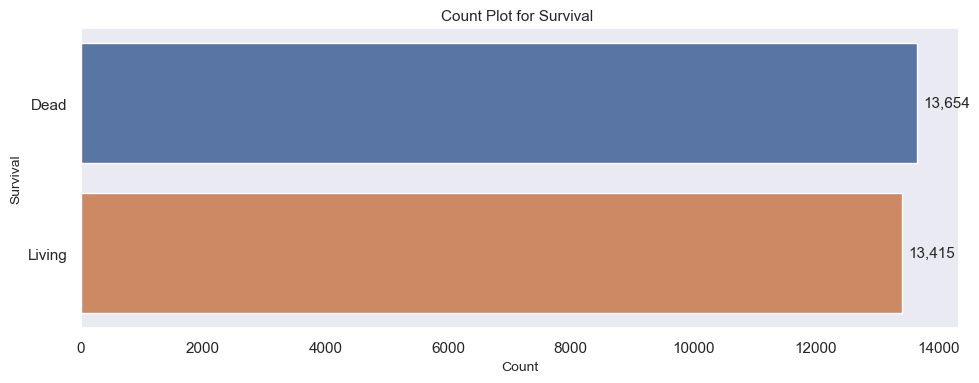

In [6]:
# remove rows where Survival is NaN
df = df.dropna(subset=['Survival'])
# print
print(f"Heart Dataset Rows: {df.shape[0]:,} & Columns: {df.shape[1]:,}")

# plot
uv.plot_count(df, ['Survival'], fig_size=(10, 4))

#### Unwanted Labels

In [7]:
# remove unwanted labels
removeCols = df_label.column.to_list()

## Ordinal Plots & Engineering

### Ordinal: Heapmap

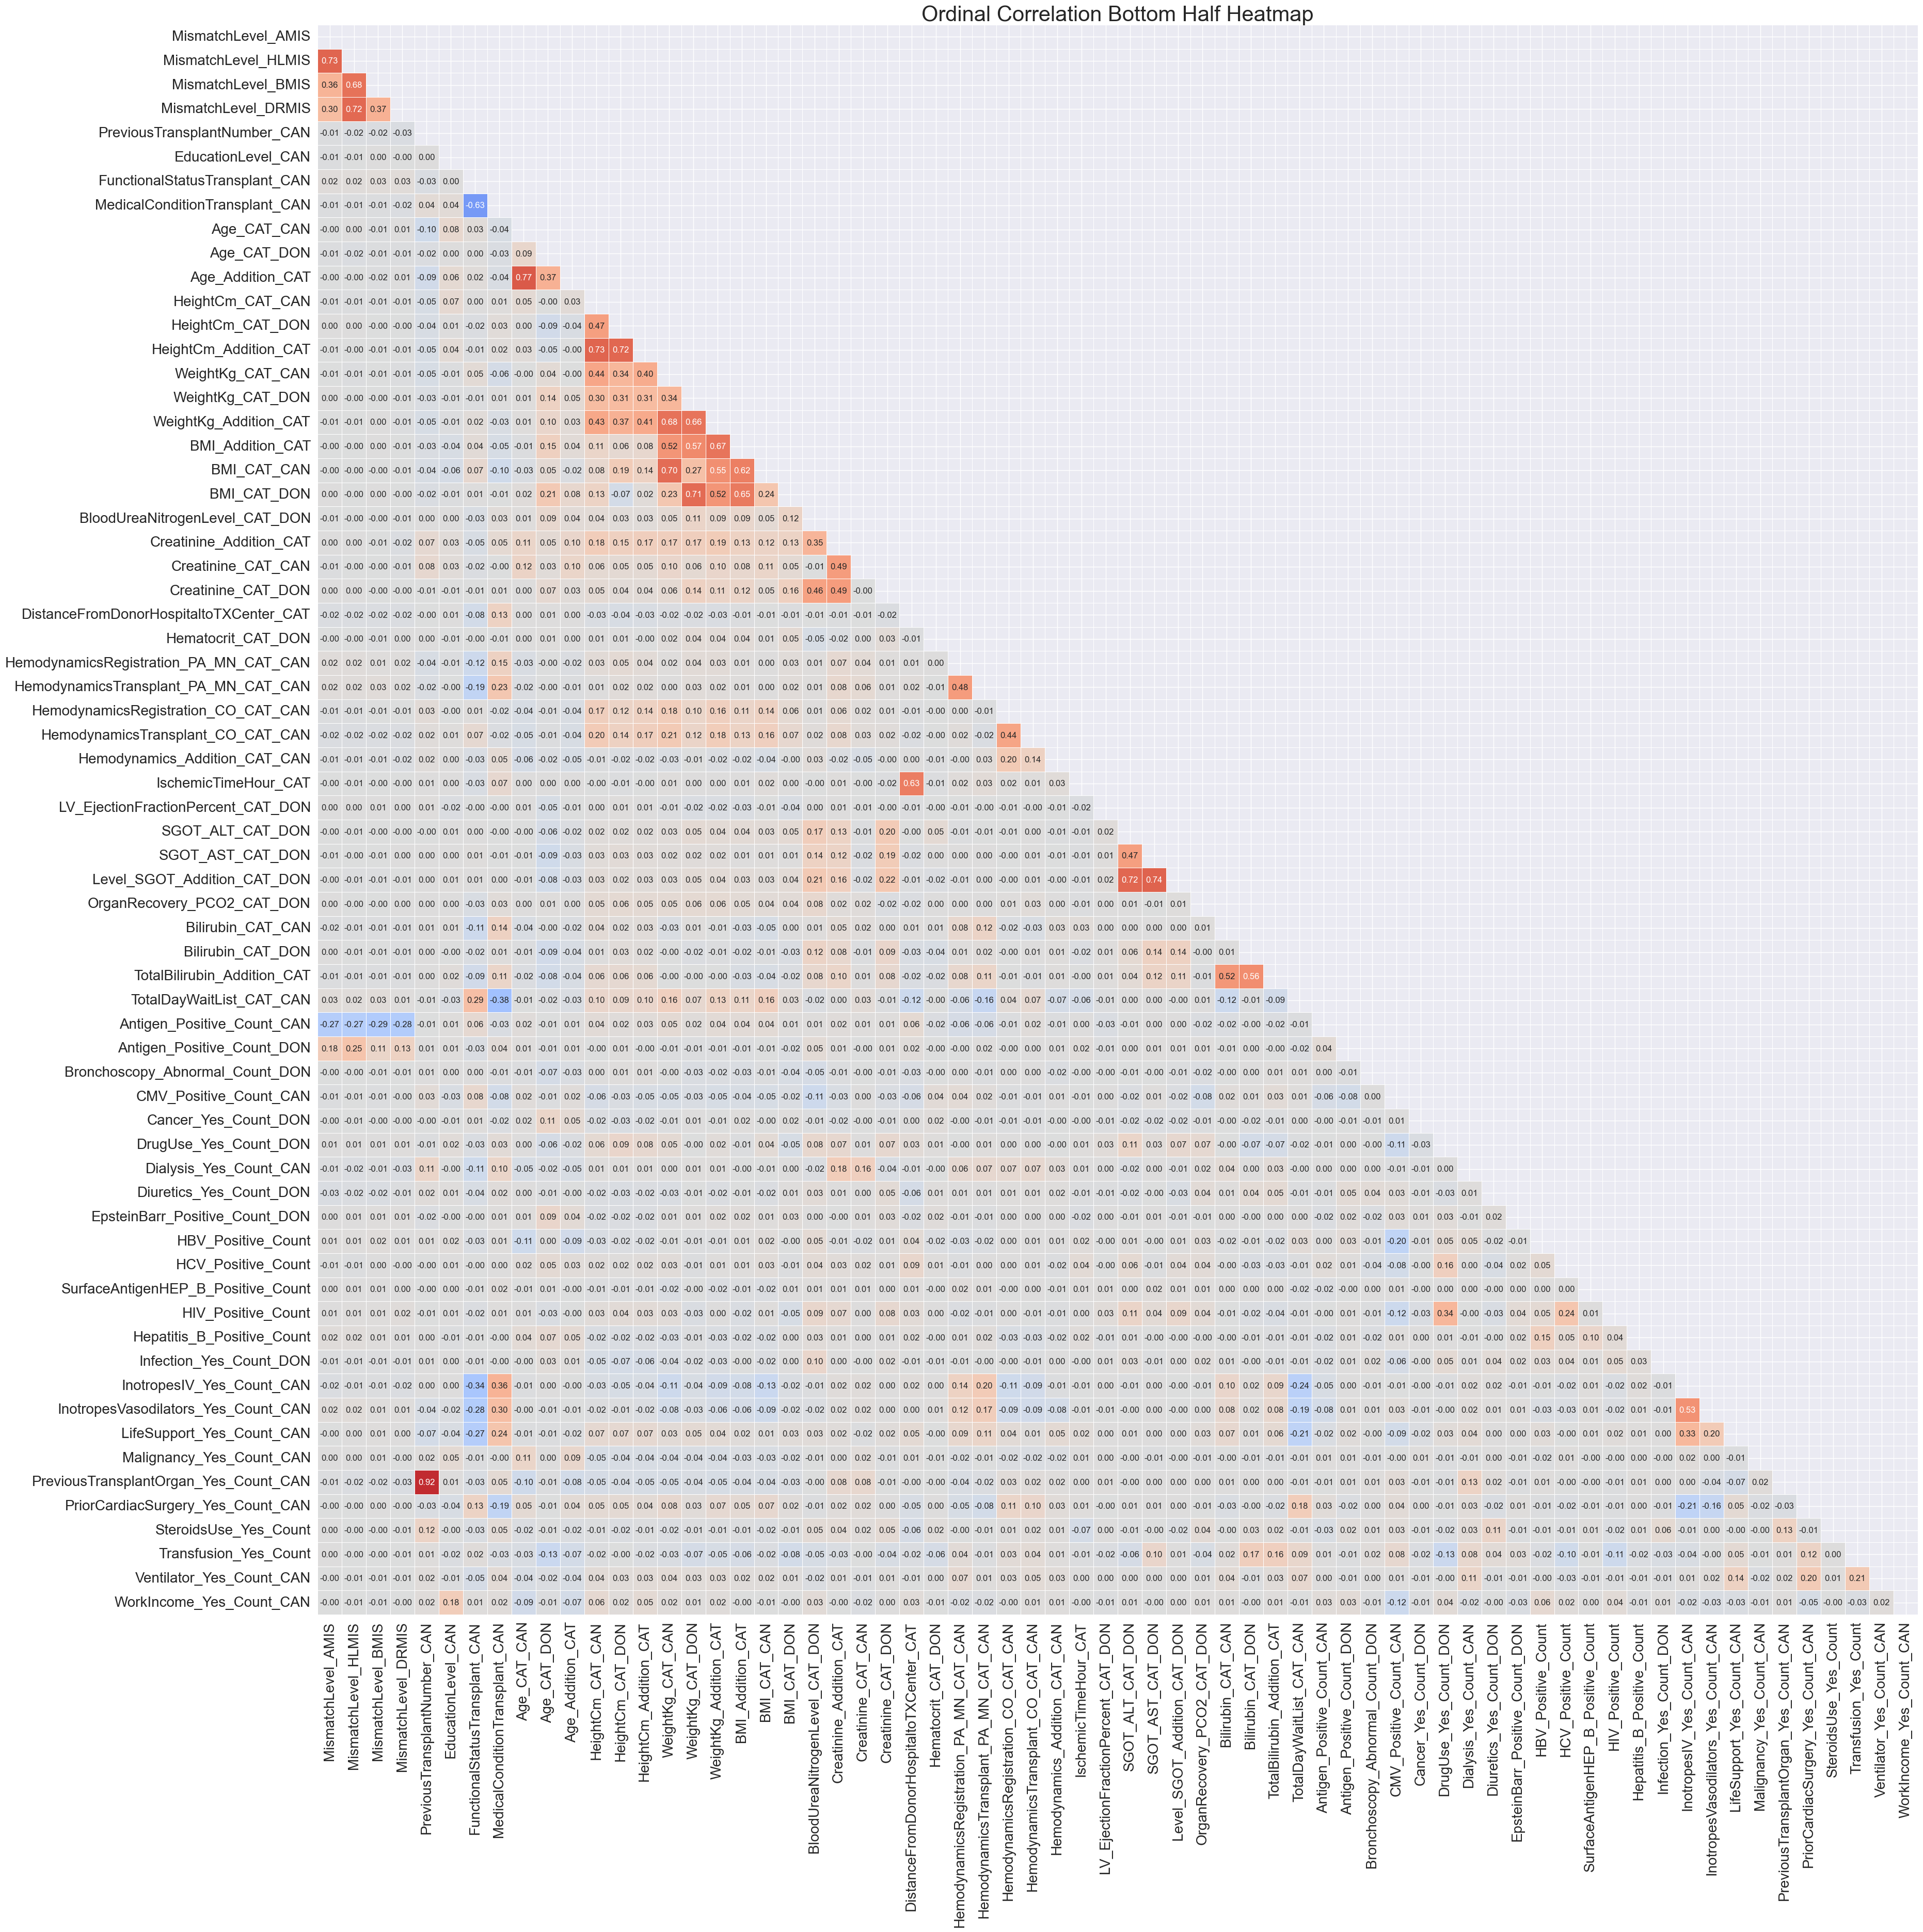

In [8]:
# compute the correlation matrix
corr_matrix = df[df_ordinal.column.to_list()].corr(method='spearman')
# create a mask for the UPPER triangle  
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  

# display options
plt.figure(figsize=(40,40))
plt.title("Ordinal Correlation Bottom Half Heatmap", fontsize=30)
plt.xticks(fontsize=20)  # font size for x-ticks
plt.yticks(fontsize=20)  # font size for y-ticks
# plot the BOTTOM half (lower triangle + diagonal)  
sns.heatmap(corr_matrix,  
            mask=mask,  # hide the upper triangle  
            annot=True,  
            cmap='coolwarm',  
            vmin=-1, vmax=1,  
            linewidths=0.5, fmt=".2f", cbar=False)  
plt.show()

### Ordinal Display & Engineering
- The ordinal features with Spearman correlation below indicate strong to very moderatly strong positive monotonic relationships between the respective variable pairs 
    - Very Strong Associations (|r| ≥ 0.7)
    - Moderate-Strong Associations (0.5 ≤ |r| < 0.7)

In [9]:
# threshold value
threshold = 0.5
# identify upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# find feature columns with correlation greater than 0.7
to_drop = [column for column in upper.columns if any(np.abs(upper[column]) > threshold)]

# display
print(f"Strong correlation: {sorted(to_drop)}\n")
# ordinal correlation: re-check
print(f"Ordinal Correlation Re-Check with Threshold of {threshold * 100}% or greater:")
usf.correlation_with_threshold(df[df_ordinal.column.to_list()], method='spearman', threshold=threshold)

Strong correlation: ['Age_Addition_CAT', 'BMI_Addition_CAT', 'BMI_CAT_CAN', 'BMI_CAT_DON', 'HeightCm_Addition_CAT', 'InotropesVasodilators_Yes_Count_CAN', 'IschemicTimeHour_CAT', 'Level_SGOT_Addition_CAT_DON', 'MedicalConditionTransplant_CAN', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantOrgan_Yes_Count_CAN', 'TotalBilirubin_Addition_CAT', 'WeightKg_Addition_CAT']

Ordinal Correlation Re-Check with Threshold of 50.0% or greater:
Correlation between MismatchLevel_AMIS and MismatchLevel_HLMIS: 0.733
Correlation between MismatchLevel_HLMIS and MismatchLevel_BMIS: 0.677
Correlation between MismatchLevel_HLMIS and MismatchLevel_DRMIS: 0.718
Correlation between PreviousTransplantNumber_CAN and PreviousTransplantOrgan_Yes_Count_CAN: 0.925
Correlation between FunctionalStatusTransplant_CAN and MedicalConditionTransplant_CAN: -0.628
Correlation between Age_CAT_CAN and Age_Addition_CAT: 0.767
Correlation between HeightCm_CAT_CAN and HeightCm_Addition_CAT

#### Engineer: MismatchLevel

In [10]:
features = uf.get_feature_list(df, 'MismatchLevel')

                       count      mean       std  min  25%  50%  75%  max
MismatchLevel_AMIS   27069.0  1.576231  0.729327  0.0  1.0  2.0  2.0  3.0
MismatchLevel_BMIS   27069.0  1.806347  0.598162  0.0  1.0  2.0  2.0  3.0
MismatchLevel_DRMIS  27069.0  1.622631  0.699389  0.0  1.0  2.0  2.0  3.0
MismatchLevel_HLMIS  27069.0  4.841959  1.208987  0.0  4.0  5.0  6.0  7.0

:::: NaN Count:
MismatchLevel_AMIS     0
MismatchLevel_BMIS     0
MismatchLevel_DRMIS    0
MismatchLevel_HLMIS    0


In [11]:
# ordinal correlation
usf.correlation_with_threshold(df[features], method='spearman', threshold=threshold)

Correlation between MismatchLevel_AMIS and MismatchLevel_HLMIS: 0.733
Correlation between MismatchLevel_BMIS and MismatchLevel_HLMIS: 0.677
Correlation between MismatchLevel_DRMIS and MismatchLevel_HLMIS: 0.718


In [12]:
# append to removeCols
removeCols.extend(features)

# combine
df['MismatchLevel_Addition'] = df[features].sum(axis=1)

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['MismatchLevel_Addition'])
df_both = uf.insert_into_dataframe(df_both, ['MismatchLevel_Addition'])
# display
uf.category_contingency_survival(df, 'MismatchLevel_Addition')

Survival,Dead,Living,Row Total,Dead %,Living %
0.0,11.0,15.0,26.0,42.307692,57.692308
2.0,49.0,52.0,101.0,48.514851,51.485149
4.0,310.0,364.0,674.0,45.994065,54.005935
6.0,1363.0,1385.0,2748.0,49.599709,50.400291
8.0,3214.0,3138.0,6352.0,50.598237,49.401763
10.0,4679.0,4582.0,9261.0,50.523702,49.476298
12.0,2927.0,2762.0,5689.0,51.450167,48.549833
13.0,1.0,2.0,3.0,33.333333,66.666667
14.0,1.0,1.0,2.0,50.000000,50.000000
15.0,0.0,2.0,2.0,0.000000,100.000000


#### Engineer: Inotropes

In [13]:
features = uf.get_feature_list(df, 'Inotropes')

                                       count      mean       std  min  25%  50%  75%   max
InotropesIV_Yes_Count_CAN            27069.0  0.715542  0.818312  0.0  0.0  0.0  1.0   2.0
InotropesVasodilators_Yes_Count_CAN  27069.0  4.006391  4.065591  0.0  0.0  5.0  9.0  10.0

:::: NaN Count:
InotropesIV_Yes_Count_CAN              0
InotropesVasodilators_Yes_Count_CAN    0


In [14]:
# ordinal correlation
usf.correlation_with_threshold(df[features], method='spearman', threshold=threshold)

Correlation between InotropesIV_Yes_Count_CAN and InotropesVasodilators_Yes_Count_CAN: 0.532


In [15]:
# append to removeCols
removeCols.extend(features)

# combine
df['Inotropes_Yes_Count_Addition_CAN'] = df[features].sum(axis=1)

# update DataFrame
df_ordinal = uf.insert_into_dataframe(df_ordinal, ['Inotropes_Yes_Count_Addition_CAN'])
df_can = uf.insert_into_dataframe(df_can, ['Inotropes_Yes_Count_Addition_CAN'])
# display
uf.category_contingency_survival(df, 'Inotropes_Yes_Count_Addition_CAN')

Survival,Dead,Living,Row Total,Dead %,Living %
0,5124.0,4500.0,9624.0,53.241895,46.758105
1,785.0,905.0,1690.0,46.449704,53.550296
2,429.0,440.0,869.0,49.367089,50.632911
3,26.0,43.0,69.0,37.681159,62.318841
4,213.0,220.0,433.0,49.191686,50.808314
5,1233.0,1507.0,2740.0,45.000000,55.000000
6,1333.0,1485.0,2818.0,47.303052,52.696948
7,658.0,686.0,1344.0,48.958333,51.041667
8,88.0,79.0,167.0,52.694611,47.305389
9,197.0,160.0,357.0,55.182073,44.817927


#### Ordinal Remove

In [16]:
# append to removeCols list
removeCols.extend(find_feature('Bilirubin_CAT', df.columns.to_list()))
removeCols.extend(find_feature('BMI_', df.columns.to_list()))
removeCols.extend(find_feature('PreviousTransplantNumber_CAN', df.columns.to_list())) 
removeCols.extend(find_feature('FunctionalStatusTransplant_CAN', df.columns.to_list()))
removeCols.extend(find_feature('Age_CAT', df.columns.to_list()))
removeCols.extend(find_feature('HeightCm_CAT', df.columns.to_list()))
removeCols.extend(find_feature('WeightKg_CAT', df.columns.to_list()))
removeCols.extend(find_feature('DistanceFromDonorHospitaltoTXCenter_CAT', df.columns.to_list()))
removeCols.extend(find_feature('SGOT_ALT_CAT_DON', df.columns.to_list()))
removeCols.extend(find_feature('SGOT_AST_CAT_DON', df.columns.to_list()))

# remove features
df, df_ordinal, df_nominal, df_can, df_don, df_both = HouseKeeping(df, removeCols, df_ordinal, df_nominal, df_can, df_don, df_both, display=True)

Remove 22 row(s) from df_ordinal DataFrame.
Remove 0 row(s) from df_nominal DataFrame.
Remove 9 row(s) from df_can DataFrame.
Remove 7 row(s) from df_don DataFrame.
Remove 0 row(s) from df_both DataFrame.

Removed Features: ['Age_CAT_CAN', 'Age_CAT_DON', 'BMI_Addition_CAT', 'BMI_CAT_CAN', 'BMI_CAT_DON', 'Bilirubin_CAT_CAN', 'Bilirubin_CAT_DON', 'DistanceFromDonorHospitaltoTXCenter_CAT', 'FunctionalStatusTransplant_CAN', 'HeightCm_CAT_CAN', 'HeightCm_CAT_DON', 'InotropesIV_Yes_Count_CAN', 'InotropesVasodilators_Yes_Count_CAN', 'LengthOfStay', 'MismatchLevel_AMIS', 'MismatchLevel_BMIS', 'MismatchLevel_DRMIS', 'MismatchLevel_HLMIS', 'PreviousTransplantNumber_CAN', 'SGOT_ALT_CAT_DON', 'SGOT_AST_CAT_DON', 'TransplantSurvivalDay', 'WeightKg_CAT_CAN', 'WeightKg_CAT_DON']

Total Row(s) & Column(s) Before Removing Column(s): 27,069 & columns: 119
Total Row(s) & Column(s) After Removing Column(s): 27,069 & columns: 95


#### Ordinal Association Testing

In [17]:
print(f"Ordinal Correlation Re-Check with Threshold of {threshold * 100}% or greater:")
usf.correlation_with_threshold(df[df_ordinal.column.to_list()], method='spearman', threshold=threshold)

Ordinal Correlation Re-Check with Threshold of 50.0% or greater:


In [18]:
mwutDF = usf.mannwhitneyu_combinations(df, df_ordinal.column.to_list())

# display p_value >= 0.05
mwutDF[(mwutDF.p_value >= 0.05)]

,column1,column2,U_statistic,p_value
936,HCV_Positive_Count,PreviousTransplantOrgan_Yes_Count_CAN,366342668.5,0.968037
89,Age_Addition_CAT,HeightCm_Addition_CAT,366595467.0,0.883822
90,Age_Addition_CAT,WeightKg_Addition_CAT,366040820.0,0.836708
1029,Ventilator_Yes_Count_CAN,WorkIncome_Yes_Count_CAN,366037837.0,0.794706
132,HeightCm_Addition_CAT,WeightKg_Addition_CAT,365810818.5,0.724715
831,Cancer_Yes_Count_DON,SurfaceAntigenHEP_B_Positive_Count,366230182.0,0.722806
980,Infection_Yes_Count_DON,LifeSupport_Yes_Count_CAN,367045818.0,0.684453
58,MedicalConditionTransplant_CAN,IschemicTimeHour_CAT,365556788.0,0.636618
265,Creatinine_Addition_CAT,Level_SGOT_Addition_CAT_DON,367557441.5,0.487121
788,Bronchoscopy_Abnormal_Count_DON,HBV_Positive_Count,365376298.5,0.404083


##### There are associations, but they are different features representing something different.

#### Ordinal Datatype Update

In [19]:
# change datatype to category
df = uf.convert_to_category(df, df_ordinal.column.to_list(), ordered=True)

## Nominal Plots & Engineering

### Nominal Chi2 Test & Cramer V

In [20]:
# hypothesis testing
nominalDF = usf.multi_independence_category(df, df_nominal.column.to_list())
# display
nominalDF[(nominalDF.p_value <= 0.05) & (nominalDF.cramer_v > .5)]

,column1,column2,chi2,p_value,cramer_v
131,AntiHypertensive_DON,Vasodilators_DON,28136.369867,0.0,0.720913
938,DeceasedRetyped_DON,CrossMatchDone,28063.772389,0.0,0.719982
189,PrimaryDiagnosisType_CAN,CigaretteUse_CAN,27341.069852,0.0,0.710651
1028,PulmonaryCatheter_DON,HeparinManagement_DON,26027.749339,0.0,0.693373
1008,ThyroxineT4_DON,PulmonaryCatheter_DON,24604.567632,0.0,0.674150
122,AntiHypertensive_DON,ThyroxineT4_DON,24410.728886,0.0,0.671490
992,TriiodothyronineT3_DON,ThyroxineT4_DON,24310.633645,0.0,0.670111
1032,PulmonaryCatheter_DON,InsulinManagement_DON,24182.431910,0.0,0.668342
167,ArginnieManagement_DON,PulmonaryCatheter_DON,23767.879105,0.0,0.662589
1018,ThyroxineT4_DON,InsulinManagement_DON,23763.734507,0.0,0.662531


### Nominal Datatype Update

In [21]:
# change datatype to category
df = uf.convert_to_category(df, df_nominal.column.to_list())

## Dummy Encoding

In [22]:
# shape
print(f"Shape before encoding: {df.shape}")
# encode
df_dummy = pd.get_dummies(df, columns=df_nominal.column.to_list(), drop_first=True)
# print shape
print(f"Shape after encoding: {df_dummy.shape}")
# add columns to list
dummyCols = df_dummy.columns.tolist()
# remove label
dummyCols.remove('Survival')

Shape before encoding: (27069, 95)
Shape after encoding: (27069, 203)


## Display GINI Information

In [23]:
# remove features with GiniPercent
percent = 5
holdDF = ufs.compute_entropy_gini_impurity(df_dummy[dummyCols])
removeCols = holdDF.ColumnName[holdDF.GiniPercent < percent].to_list()
print(f"Number of Features to be removed: {len(removeCols)}")
holdDF.sample(20)

Number of Features to be removed: 63


,ColumnName,NumberOfCategories,Entropy,MaxEntropy,EntropyPercent,GiniImpurity,MaxGiniImpurity,GiniPercent
29,EpsteinBarr_Positive_Count_DON,3,0.590395,1.584963,37.249805,0.215223,0.666667,32.283405
103,DefibrillatorImplantRegistration_CAN_Unknown,2,0.103550,1.000000,10.355000,0.026748,0.500000,5.349651
24,CMV_Positive_Count_CAN,3,0.683946,1.584963,43.152190,0.273716,0.666667,41.057355
52,ArginnieManagement_DON_Unknown,2,0.021758,1.000000,2.175774,0.004203,0.500000,0.840518
43,WorkIncome_Yes_Count_CAN,3,0.943531,1.584963,59.530175,0.350894,0.666667,52.634045
21,Antigen_Positive_Count_CAN,18,2.802450,4.169925,67.206243,0.749968,0.944444,79.408395
71,PrimaryDiagnosisType_CAN_HEART RE-TX/GF: ACUTE REJECTION,2,0.011382,1.000000,1.138235,0.001993,0.500000,0.398582
35,Infection_Yes_Count_DON,5,1.537597,2.321928,66.220710,0.590318,0.800000,73.789746
113,StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,2,0.300594,1.000000,30.059374,0.101065,0.500000,20.212980
135,TransplantRegion_Region 11,2,0.546706,1.000000,54.670638,0.220431,0.500000,44.086136


In [24]:
# features to be removed
holdDF[holdDF.ColumnName.isin(removeCols)].sample(10)

,ColumnName,NumberOfCategories,Entropy,MaxEntropy,EntropyPercent,GiniImpurity,MaxGiniImpurity,GiniPercent
74,PrimaryDiagnosisType_CAN_HEART RE-TX/GF: HYPERACUTE REJECTION,2,0.000597,1.000000,0.059725,0.000074,0.500000,0.014777
85,PrimaryDiagnosisType_CAN_RESTRICTIVE MYOPATHY: IDIOPATHIC,2,0.051710,1.000000,5.170970,0.011606,0.500000,2.321146
62,PrimaryDiagnosisType_CAN_DILATED MYOPATHY: ALCOHOLIC,2,0.026586,1.000000,2.658593,0.005306,0.500000,1.061118
50,AntiHypertensive_DON_Unknown,2,0.022413,1.000000,2.241261,0.004350,0.500000,0.869946
130,HeartProcedureType_CAN_Unknown,2,0.020768,1.000000,2.076837,0.003982,0.500000,0.796369
128,Ethnicity_DON_Native Hawaiian/other Pacific Islander,2,0.020768,1.000000,2.076837,0.003982,0.500000,0.796369
80,PrimaryDiagnosisType_CAN_MUSCULAR DYSTROPHY: OTHER SPECIFY,2,0.007977,1.000000,0.797737,0.001329,0.500000,0.265810
167,NonHeartBeating_DON_Yes,2,0.081358,1.000000,8.135834,0.019967,0.500000,3.993449
191,MyocardialInfarctionHistory_DON_Yes,2,0.063717,1.000000,6.371668,0.014886,0.500000,2.977245
32,SurfaceAntigenHEP_B_Positive_Count,3,0.113472,1.584963,7.159280,0.029693,0.666667,4.453955


## Split Dataset

In [25]:
from sklearn.model_selection import train_test_split

# encoded DataFrame
df_dummy = df_dummy.drop(columns=removeCols)
# print shape
print(f"Encode & Remove Features with GINI: Heart Dataset Rows: {df_dummy.shape[0]:,} & Columns: {df_dummy.shape[1]:,}")

# house keeping
ordinalCols = list(set(df_ordinal.column.to_list()) - set(removeCols))

# split X & y
X = df_dummy.drop(columns = 'Survival')
y = df_dummy.Survival

# mapping values
y = y.map({'Dead': True, 'Living': False})
# print
print(f"Dead: {True} & Living: {False}")

# split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

Encode & Remove Features with GINI: Heart Dataset Rows: 27,069 & Columns: 140
Dead: True & Living: False


## Scale

In [26]:
from sklearn.preprocessing import MinMaxScaler

# initialize MinMaxScaler
scale = MinMaxScaler()

# fit
fitScale = scale.fit(X_train[ordinalCols])

# transform
X_train[ordinalCols] = fitScale.transform(X_train[ordinalCols])
X_test[ordinalCols] = fitScale.transform(X_test[ordinalCols])

In [27]:
# message for dataframe
msg = f"2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < {percent}% removed"

## Custom Score Function

Youden’s J statistic (also called Youden’s Index) is a single-number summary of a binary classification model’s performance. It balances sensitivity (recall for positive class) and specificity (recall for negative class).
- `Youden’s J=Sensitivity + Specificity − 1`

In [28]:
from sklearn.metrics import confusion_matrix, make_scorer, matthews_corrcoef

def youdens_j_score(y_true, y_pred):
    """
    Compute Youden's J statistic.
    J = Sensitivity + Specificity - 1
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return sensitivity + specificity - 1


# define MCC scorer
mcc_scorer = make_scorer(matthews_corrcoef)

# scikit-learn scorer
youden_scorer = make_scorer(youdens_j_score, greater_is_better=True)

# define MCC scorer
mcc_scorer = make_scorer(matthews_corrcoef)

## Custom Score Function

In [29]:
from sklearn.metrics import confusion_matrix, make_scorer

def youdens_j_score(y_true, y_pred):
    """
    Compute Youden's J statistic.
    J = Sensitivity + Specificity - 1
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return sensitivity + specificity - 1

# scikit-learn scorer
youden_scorer = make_scorer(youdens_j_score, greater_is_better=True)

## Machine Learning

### RandomForestClassifier

In [30]:
from skopt.space import Real, Integer, Categorical
from sklearn.ensemble import RandomForestClassifier
# function from sklearn.utils.class_weight computes the weights for each class to handle imbalanced datasets
from sklearn.utils.class_weight import compute_class_weight

# the 'balanced' mode adjusts weights inversely proportional to class frequencies in the input data for Random Forest
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), class_weights))

# define the search space
search_space = parms.rfc_search_space()

# Initialize Model with class weights
rfc_param = {'random_state': RANDOM_STATE}

# instantiate Random Forest Classifier
Model = RandomForestClassifier(**rfc_param)

# Hyper-Parameter tuning
rfc_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = rfc_fit

Best parameters found: OrderedDict([('class_weight', 'balanced_subsample'), ('max_depth', 10), ('max_features', 'sqrt'), ('min_samples_split', 10), ('n_estimators', 498)])
Best score achieved: 0.6785311152345975

Current Model Parameters:
 RandomForestClassifier(class_weight='balanced_subsample', max_depth=10,
                       min_samples_split=10, n_estimators=498,
                       random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.98      0.86     10732
        True       0.97      0.72      0.83     10923

    accuracy                           0.85     21655
   macro avg       0.87      0.85      0.84     21655
weighted avg       0.87      0.85      0.84     21655



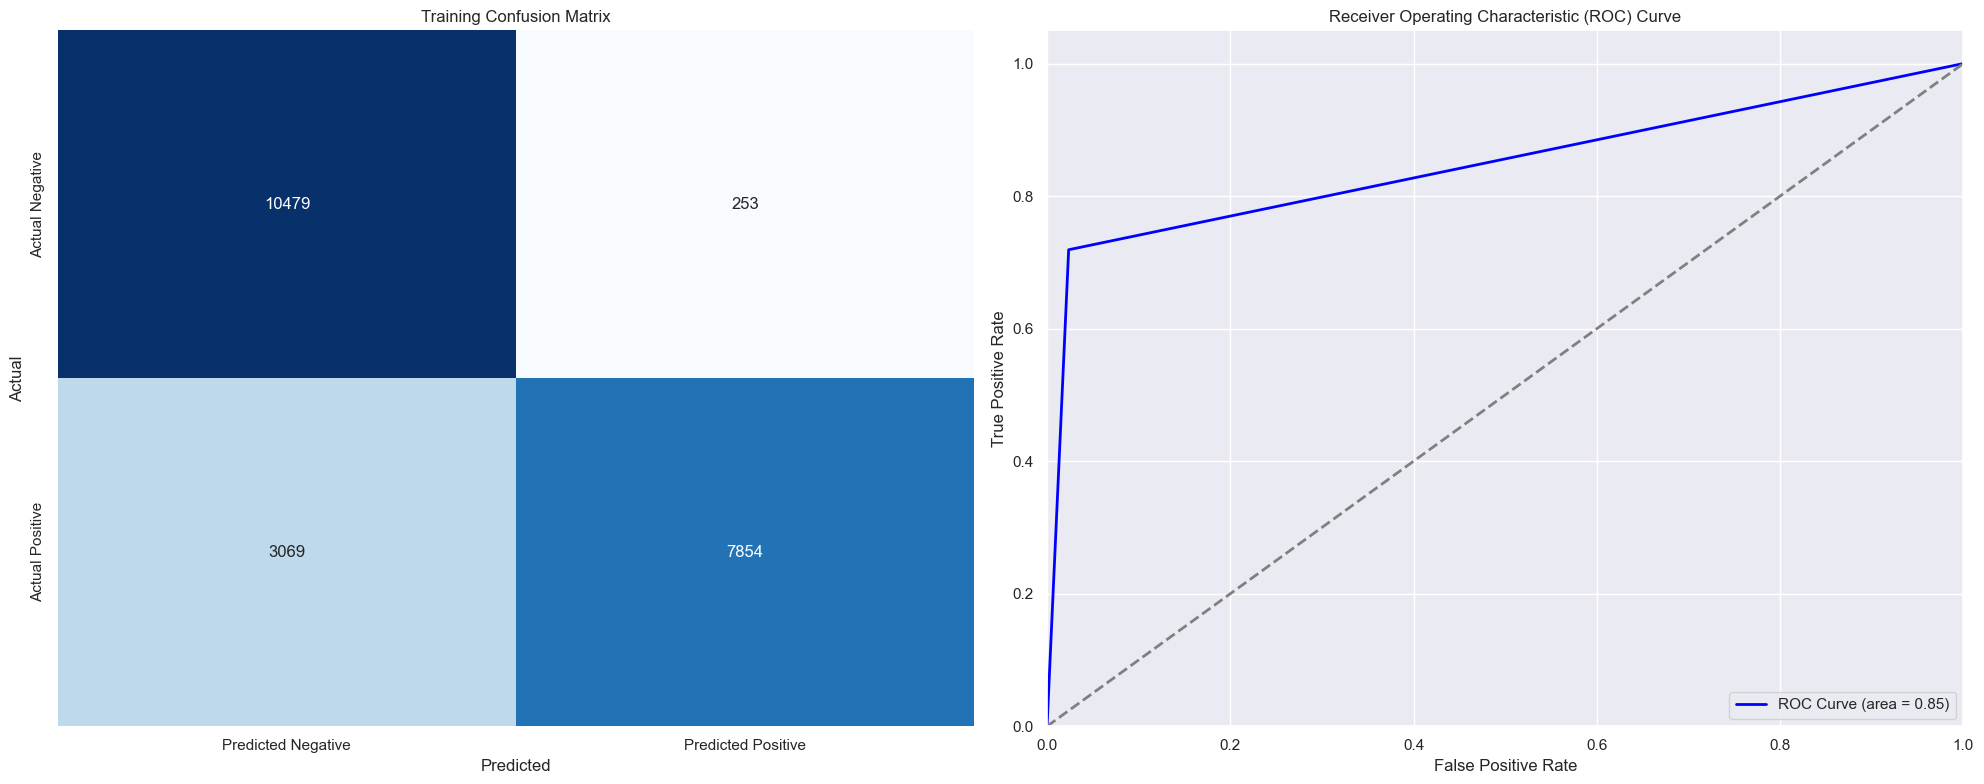

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729


In [31]:
# initialize variables
algorithm = 'RandomForestClassifier'
desc = f'{algorithm} + {msg}'
model = 'rfc_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=None, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.97      0.86      2683
        True       0.96      0.72      0.82      2731

    accuracy                           0.84      5414
   macro avg       0.87      0.84      0.84      5414
weighted avg       0.87      0.84      0.84      5414



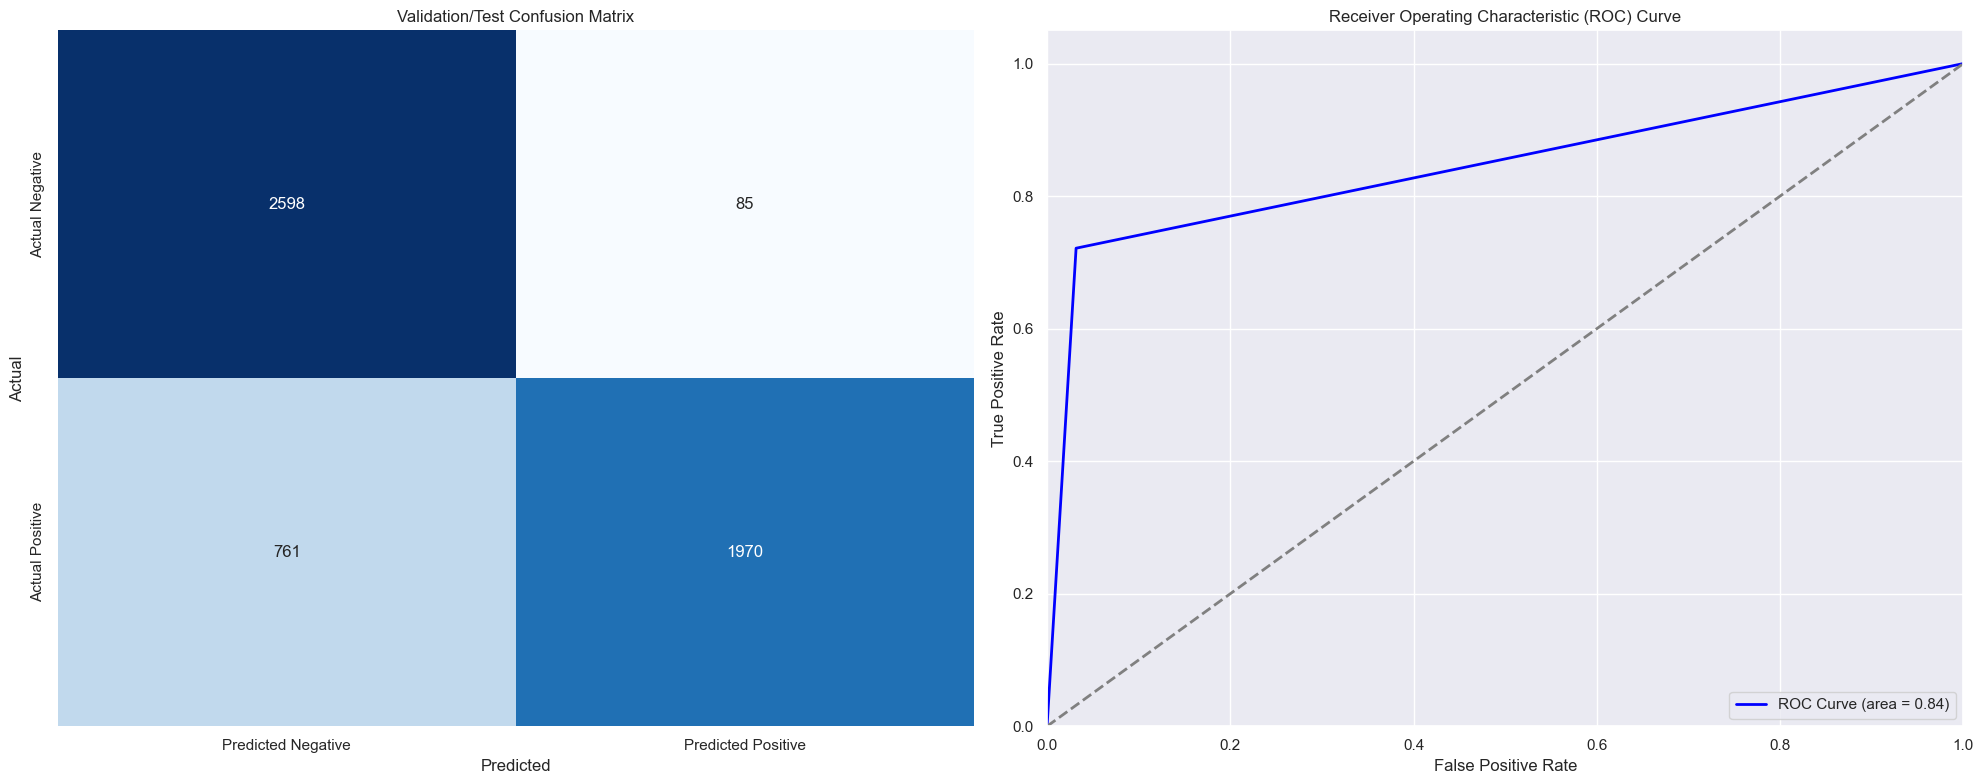

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833


In [32]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type,  metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

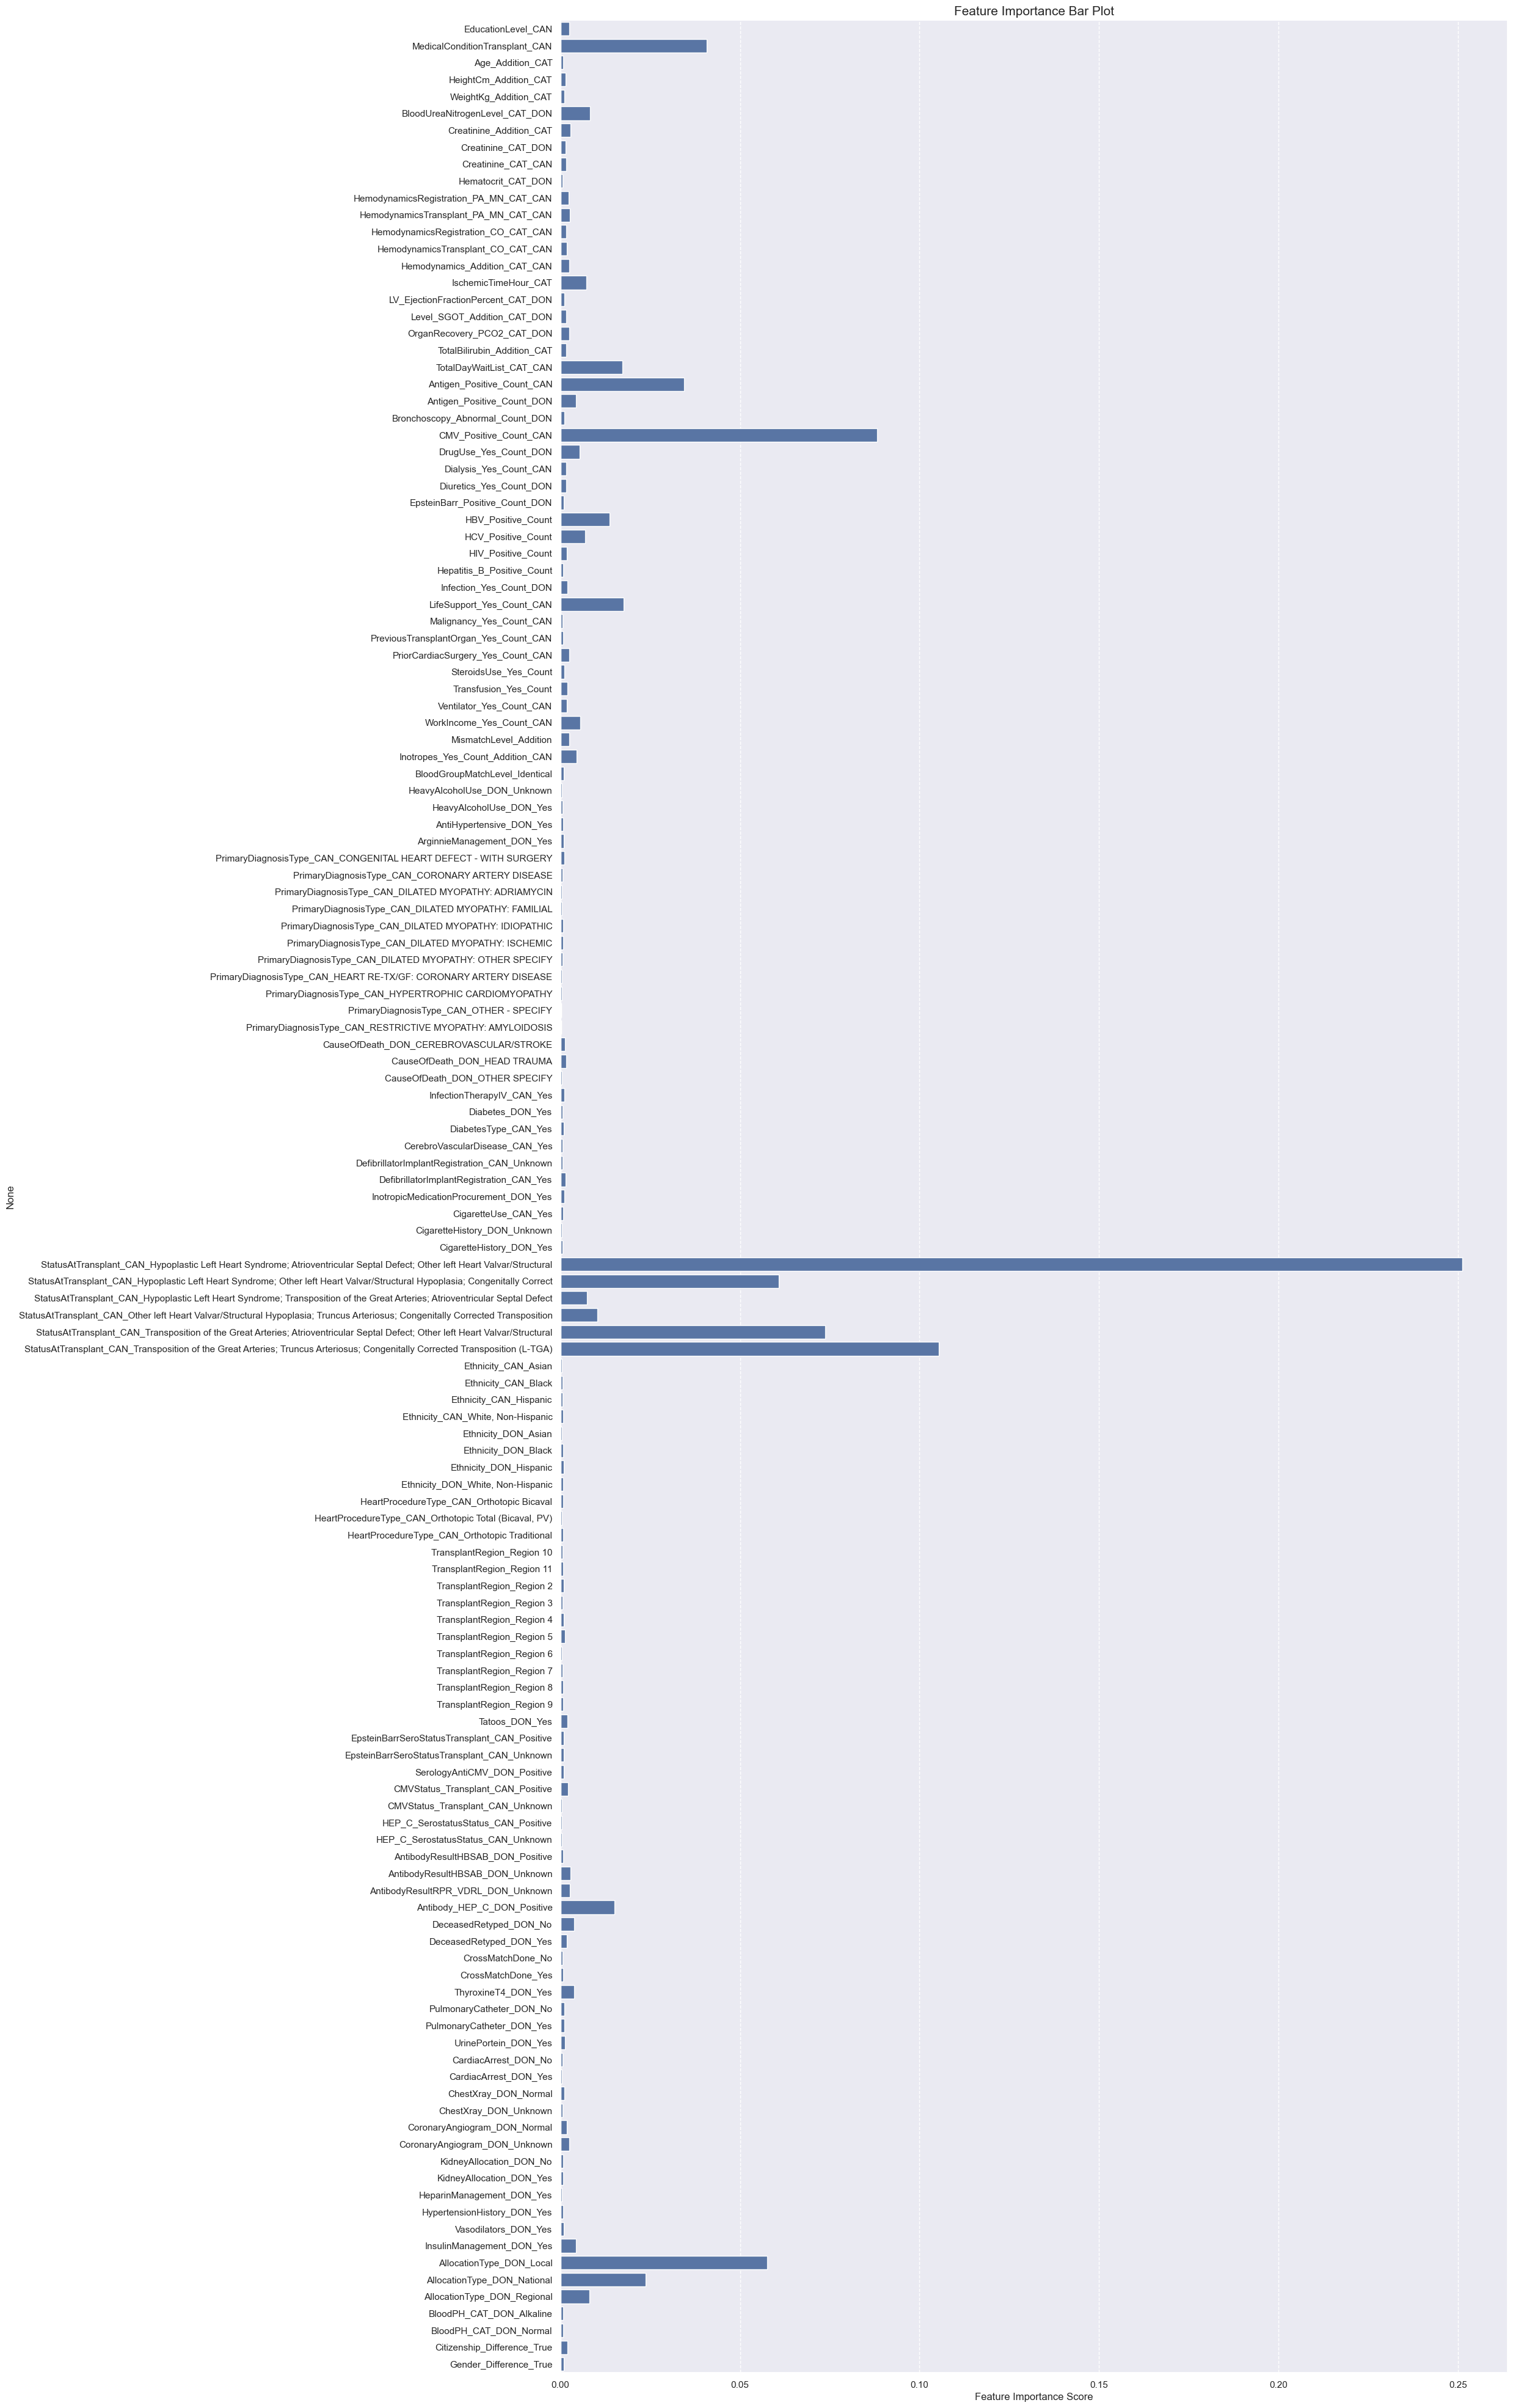

In [33]:
df_rfc = umf.plot_feature_importance(Model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [34]:
df_rfc.sort_values(by='Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.251136
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.105340
CMV_Positive_Count_CAN,0.088261
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.073755
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.060829
AllocationType_DON_Local,0.057504
MedicalConditionTransplant_CAN,0.040771
Antigen_Positive_Count_CAN,0.034470
AllocationType_DON_National,0.023700
LifeSupport_Yes_Count_CAN,0.017530


### LogisticRegression

In [35]:
# import library
from sklearn.linear_model import LogisticRegression

# define the search space
search_space = parms.lrc_search_space()

# Base Model
lrc_param = {'max_iter':10000, 'random_state': RANDOM_STATE, 'solver': 'saga', 'penalty': 'elasticnet'}

# instantiate LogisticRegression Classifier
Model = LogisticRegression(**lrc_param)

# Hyper-Parameter tuning
lrc_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = lrc_fit

Best parameters found: OrderedDict([('C', 0.11681782366726237), ('class_weight', 'balanced'), ('l1_ratio', 1.0)])
Best score achieved: 0.6764490283157487

Current Model Parameters:
 LogisticRegression(C=0.11681782366726237, class_weight='balanced', l1_ratio=1.0,
                   max_iter=10000, penalty='elasticnet', random_state=1776,
                   solver='saga')


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.97      0.86     10732
        True       0.96      0.71      0.82     10923

    accuracy                           0.84     21655
   macro avg       0.86      0.84      0.84     21655
weighted avg       0.86      0.84      0.84     21655



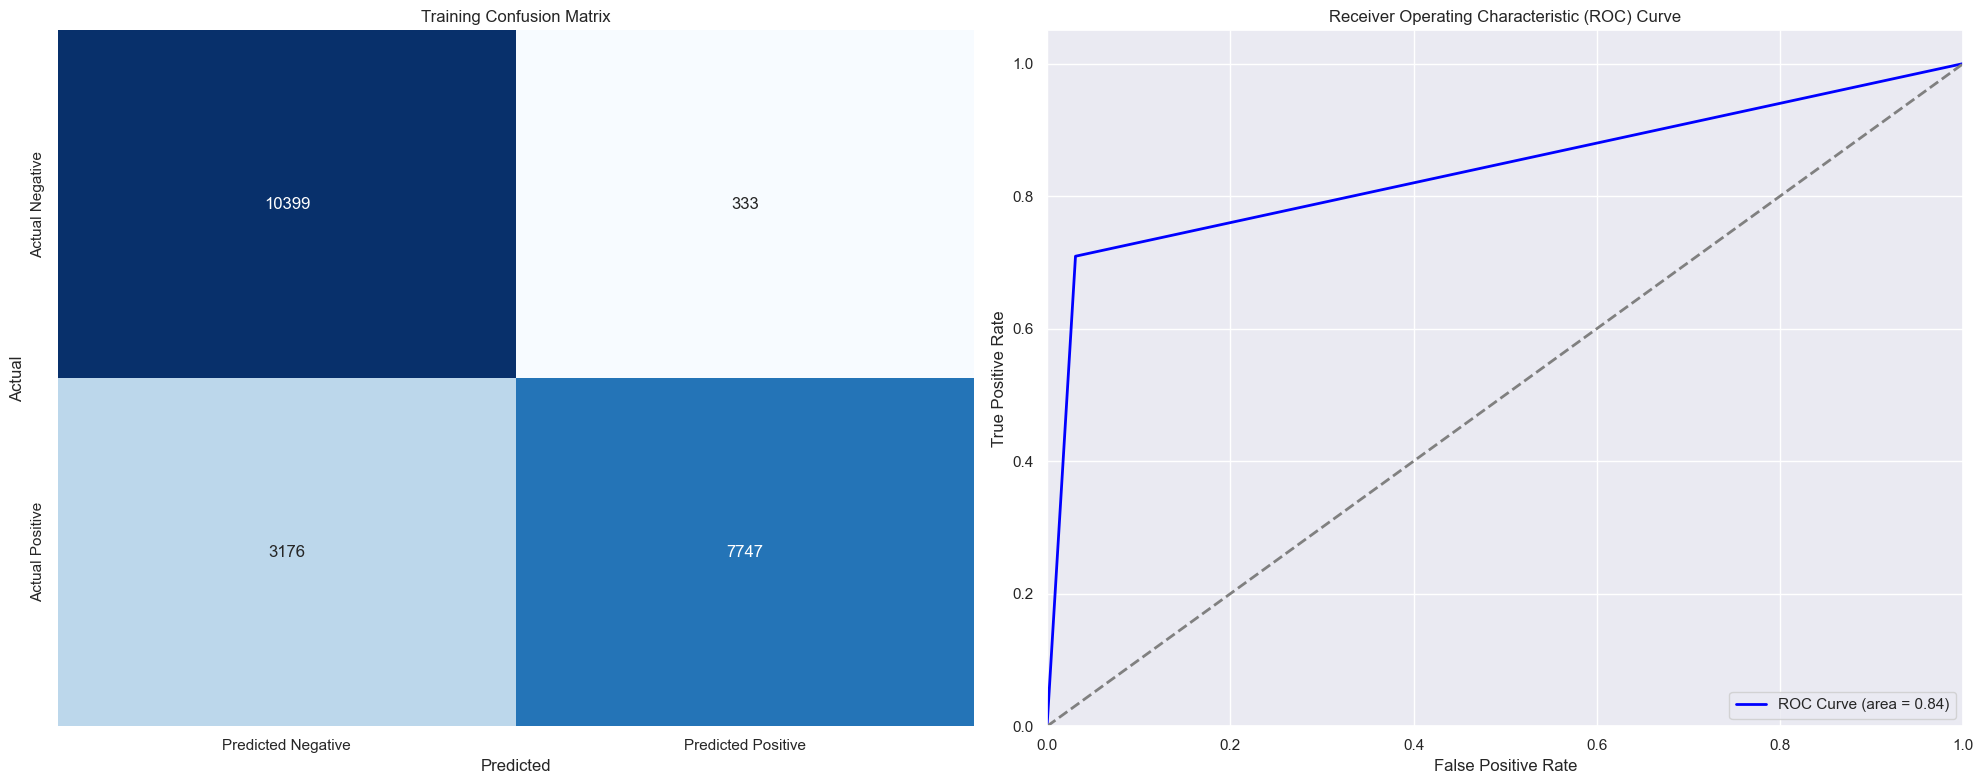

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833
2,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.837959,0.709237,0.815345,0.826671,0.958787,0.968971,0.839104


In [36]:
# initialize variables
algorithm = 'LogisticRegression'
desc = f'{algorithm} + {msg}'
model = 'lrc_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.97      0.86      2683
        True       0.96      0.72      0.82      2731

    accuracy                           0.84      5414
   macro avg       0.86      0.84      0.84      5414
weighted avg       0.87      0.84      0.84      5414



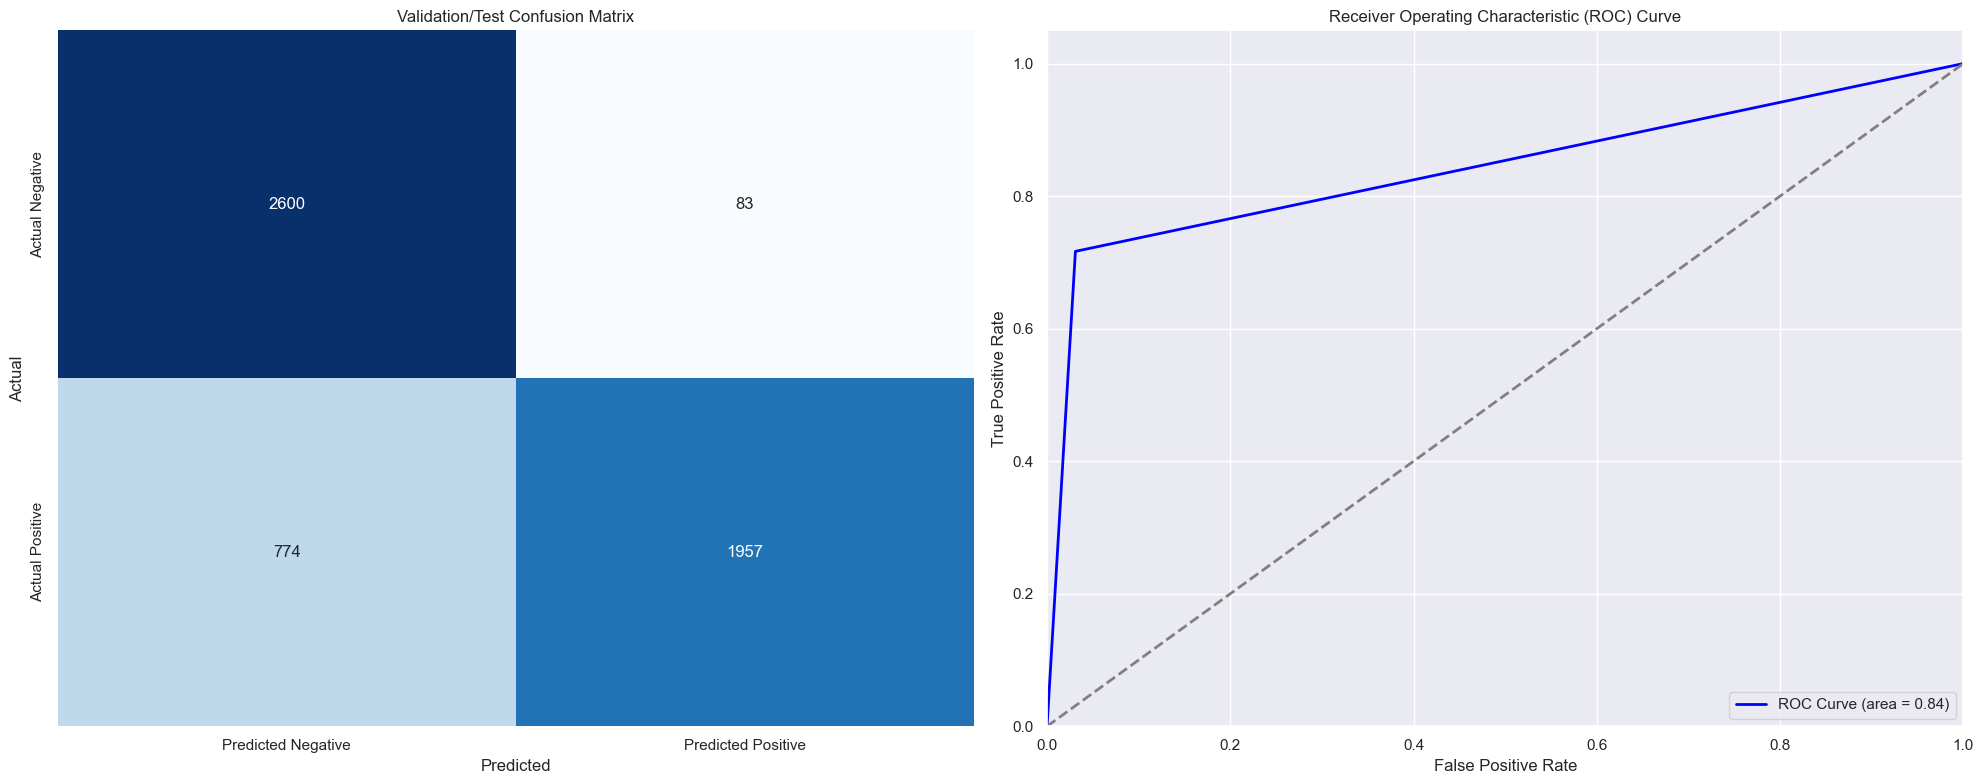

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833
2,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.837959,0.709237,0.815345,0.826671,0.958787,0.968971,0.839104
3,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841707,0.716587,0.820373,0.830395,0.959314,0.969064,0.842826


In [37]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

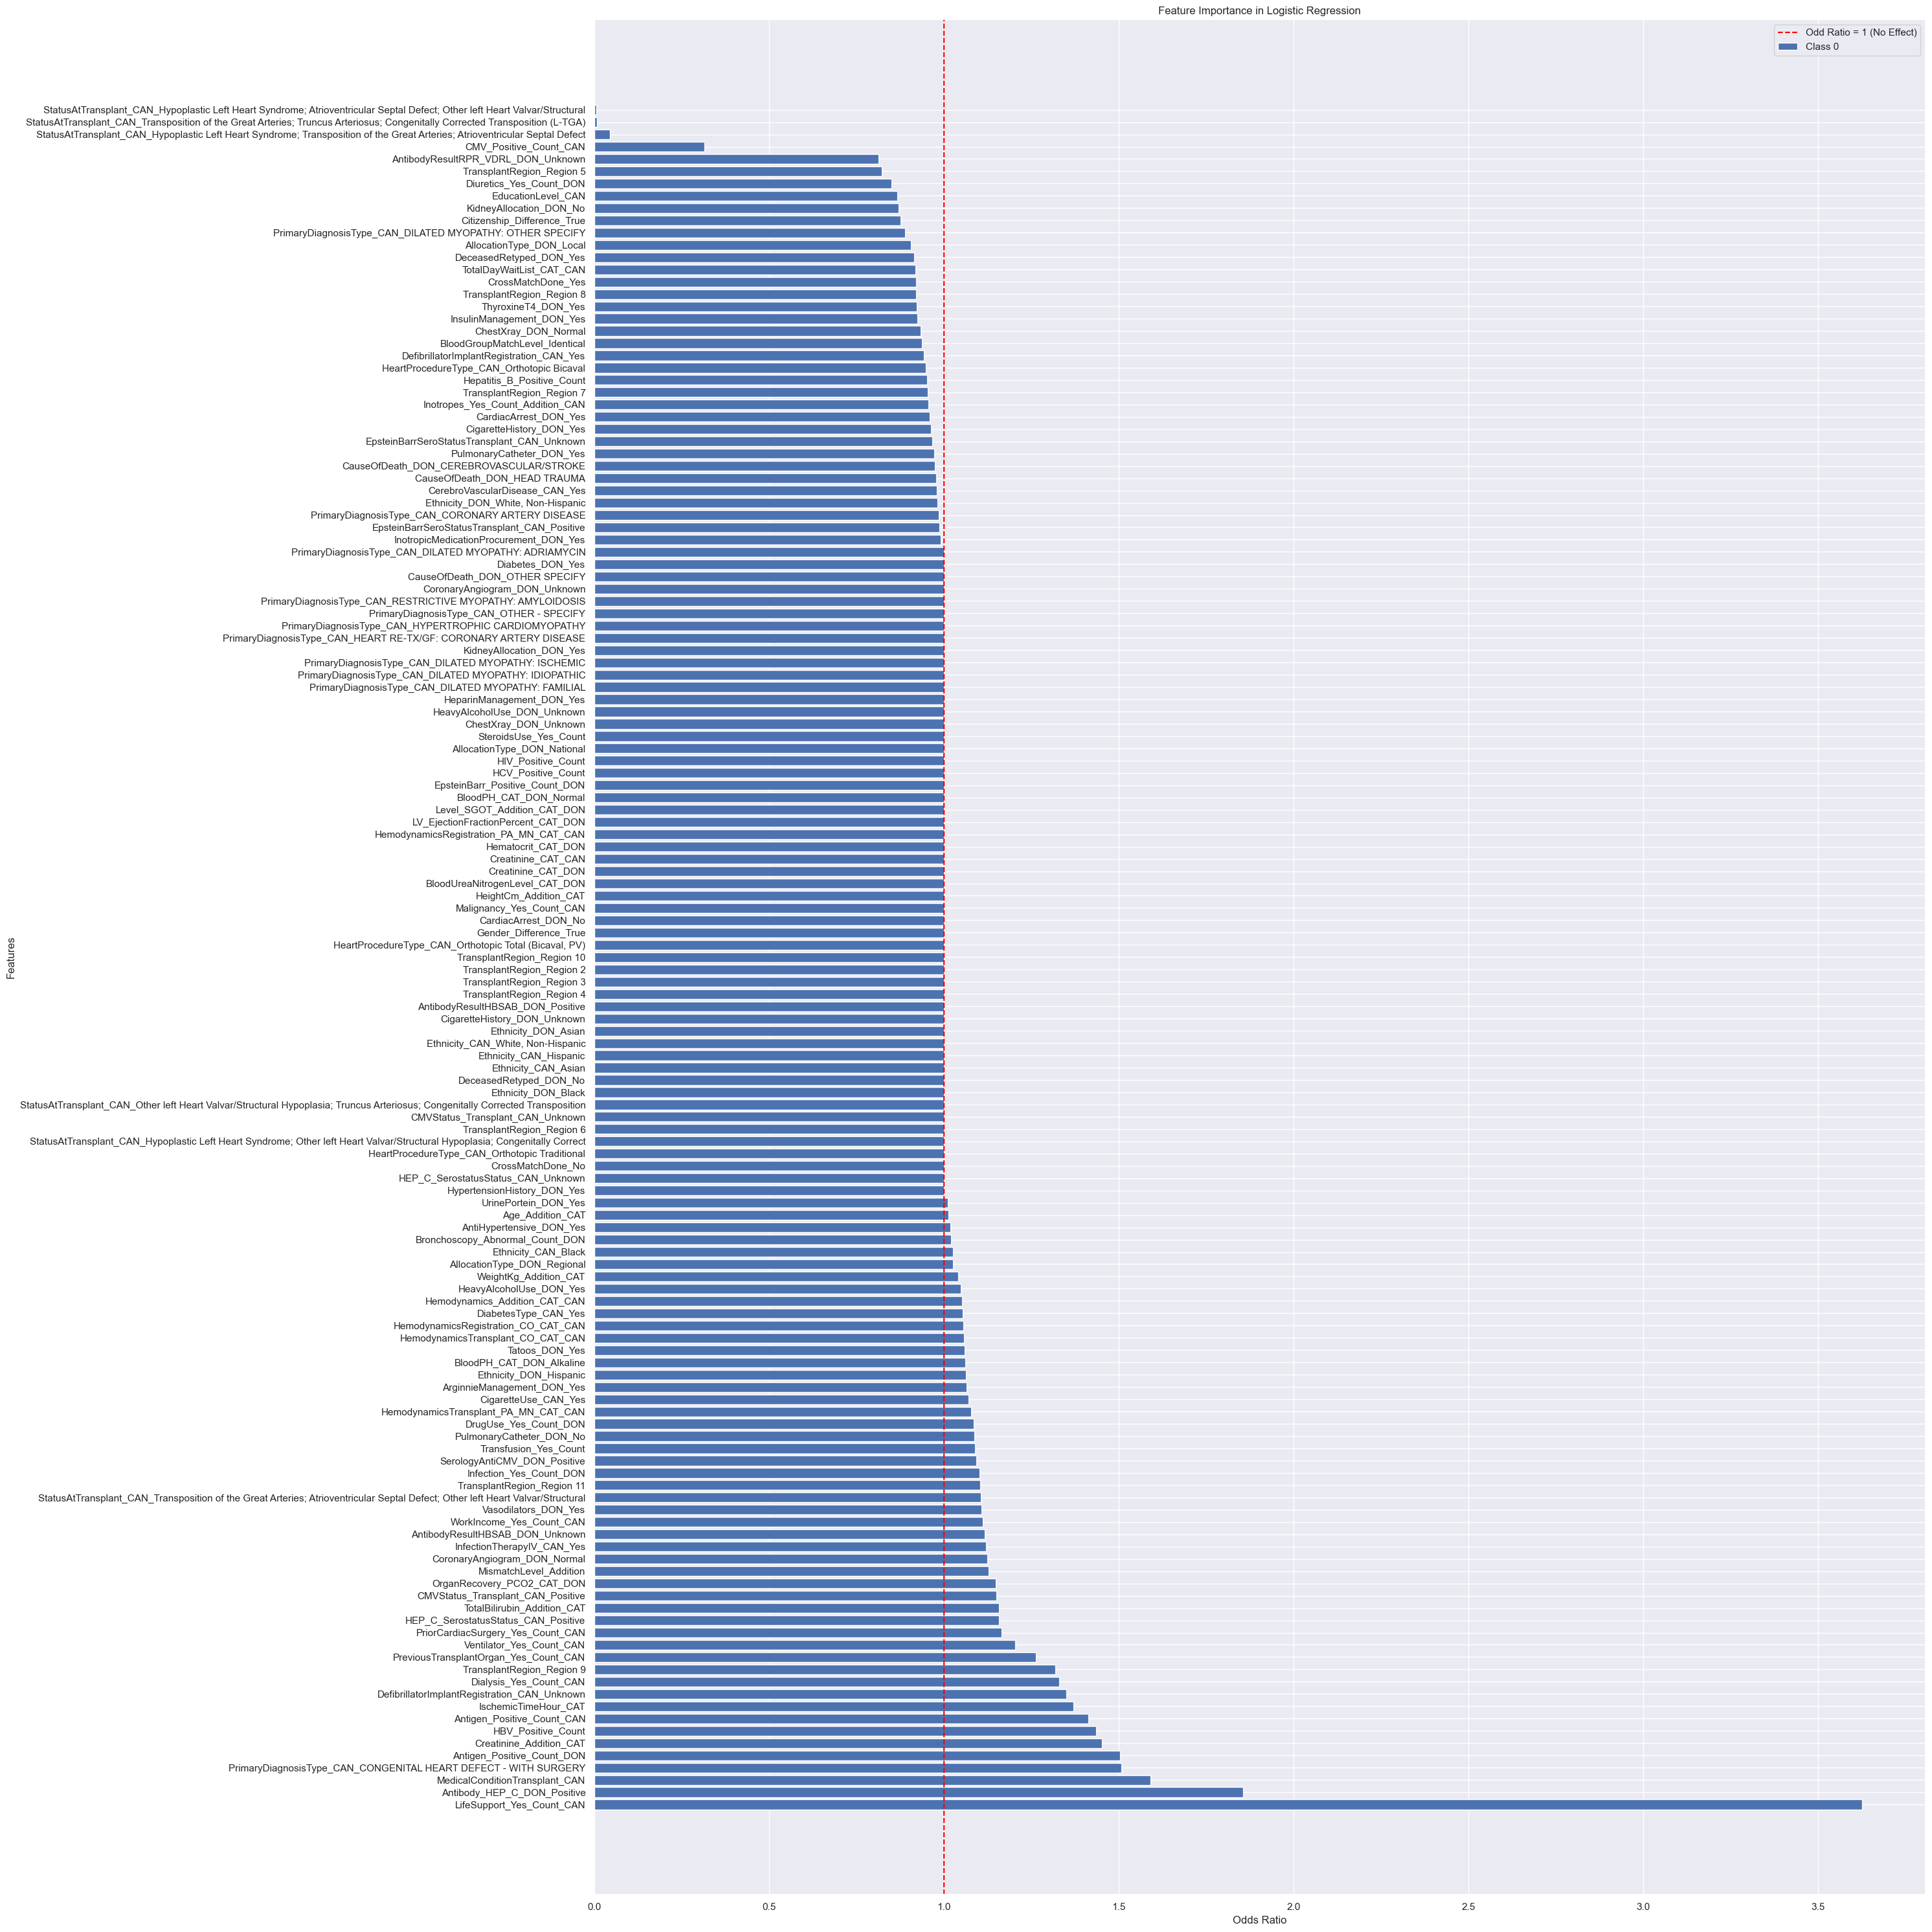

In [38]:
df_lrc = umf.logistic_feature_importance(Model, figsize=(30,30), fontsize=6)

In [39]:
df_lrc.sort_values(by='Coefficient', ascending=False).head(20)

,Feature,Coefficient,Description,Odd Ratio,Percentage Change in Odds,Probability,Class
0,LifeSupport_Yes_Count_CAN,1.287985,Increase in the log-odds of the Positive Class,3.625474,262.547430,0.783806,Class 0
1,Antibody_HEP_C_DON_Positive,0.618642,Increase in the log-odds of the Positive Class,1.856405,85.640535,0.649910,Class 0
2,MedicalConditionTransplant_CAN,0.463956,Increase in the log-odds of the Positive Class,1.590353,59.035271,0.613952,Class 0
3,PrimaryDiagnosisType_CAN_CONGENITAL HEART DEFECT - WITH SURGERY,0.410214,Increase in the log-odds of the Positive Class,1.507140,50.713999,0.601139,Class 0
4,Antigen_Positive_Count_DON,0.408490,Increase in the log-odds of the Positive Class,1.504545,50.454491,0.600726,Class 0
5,Creatinine_Addition_CAT,0.372700,Increase in the log-odds of the Positive Class,1.451649,45.164882,0.592111,Class 0
6,HBV_Positive_Count,0.362002,Increase in the log-odds of the Positive Class,1.436201,43.620146,0.589525,Class 0
7,Antigen_Positive_Count_CAN,0.345734,Increase in the log-odds of the Positive Class,1.413026,41.302635,0.585583,Class 0
8,IschemicTimeHour_CAT,0.314737,Increase in the log-odds of the Positive Class,1.369900,36.989952,0.578041,Class 0
9,DefibrillatorImplantRegistration_CAN_Unknown,0.300825,Increase in the log-odds of the Positive Class,1.350973,35.097285,0.574644,Class 0


### XGBClassifier

#### Explanation of the Gamma Parameter
- In XGBoost, the regularization term that controls the minimum loss reduction required to make a split at a node is known as the "gamma" parameter. This parameter plays a crucial role in the decision-making process of the algorithm during the tree construction phase.
- Definition: The gamma parameter specifies the minimum loss reduction required to make a further partition on a leaf node of the tree. If the reduction in loss from making a split is less than gamma, then that split will not be made.
- Purpose: By setting a higher value for gamma, you can prevent overfitting by making the model more conservative. It effectively controls how complex the model can become by limiting the number of splits. A lower gamma allows more splits and can lead to a more complex model.
- Impact on Model Complexity:
    - High Gamma Value: Results in fewer splits, leading to simpler trees that may underfit the data.
    - Low Gamma Value: Allows more splits, potentially leading to more complex trees that may overfit the training data.

The gamma parameter is essential for controlling the complexity of models built using XGBoost by regulating how much improvement in loss is necessary for splitting nodes. Adjusting this parameter can help balance between bias and variance, thus improving model performance on unseen data.

In [40]:
# import library
from xgboost import XGBClassifier

# calculate the scale_pos_weight to adjust for class imbalance
# helps to counteract the imbalance by giving more weight to the minority class (usually the positive class in binary classification).
scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)

# define the search space
search_space = parms.xgbc_search_space(scale_pos_weight)

# Base Model
xgb_param = {'random_state': RANDOM_STATE}

# instantiate XGB Classifier
Model = XGBClassifier(**xgb_param)

# Hyper-Parameter tuning
xgb_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = xgb_fit

Best parameters found: OrderedDict([('colsample_bytree', 0.8618706604596085), ('gamma', 4.0), ('learning_rate', 0.013070552244353857), ('max_depth', 10), ('n_estimators', 500), ('scale_pos_weight', 1.0), ('subsample', 1.0)])
Best score achieved: 0.6858082754213787

Current Model Parameters:
 XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8618706604596085, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=4.0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.013070552244353857, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_

#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.99      0.87     10732
        True       0.99      0.72      0.83     10923

    accuracy                           0.85     21655
   macro avg       0.88      0.85      0.85     21655
weighted avg       0.88      0.85      0.85     21655



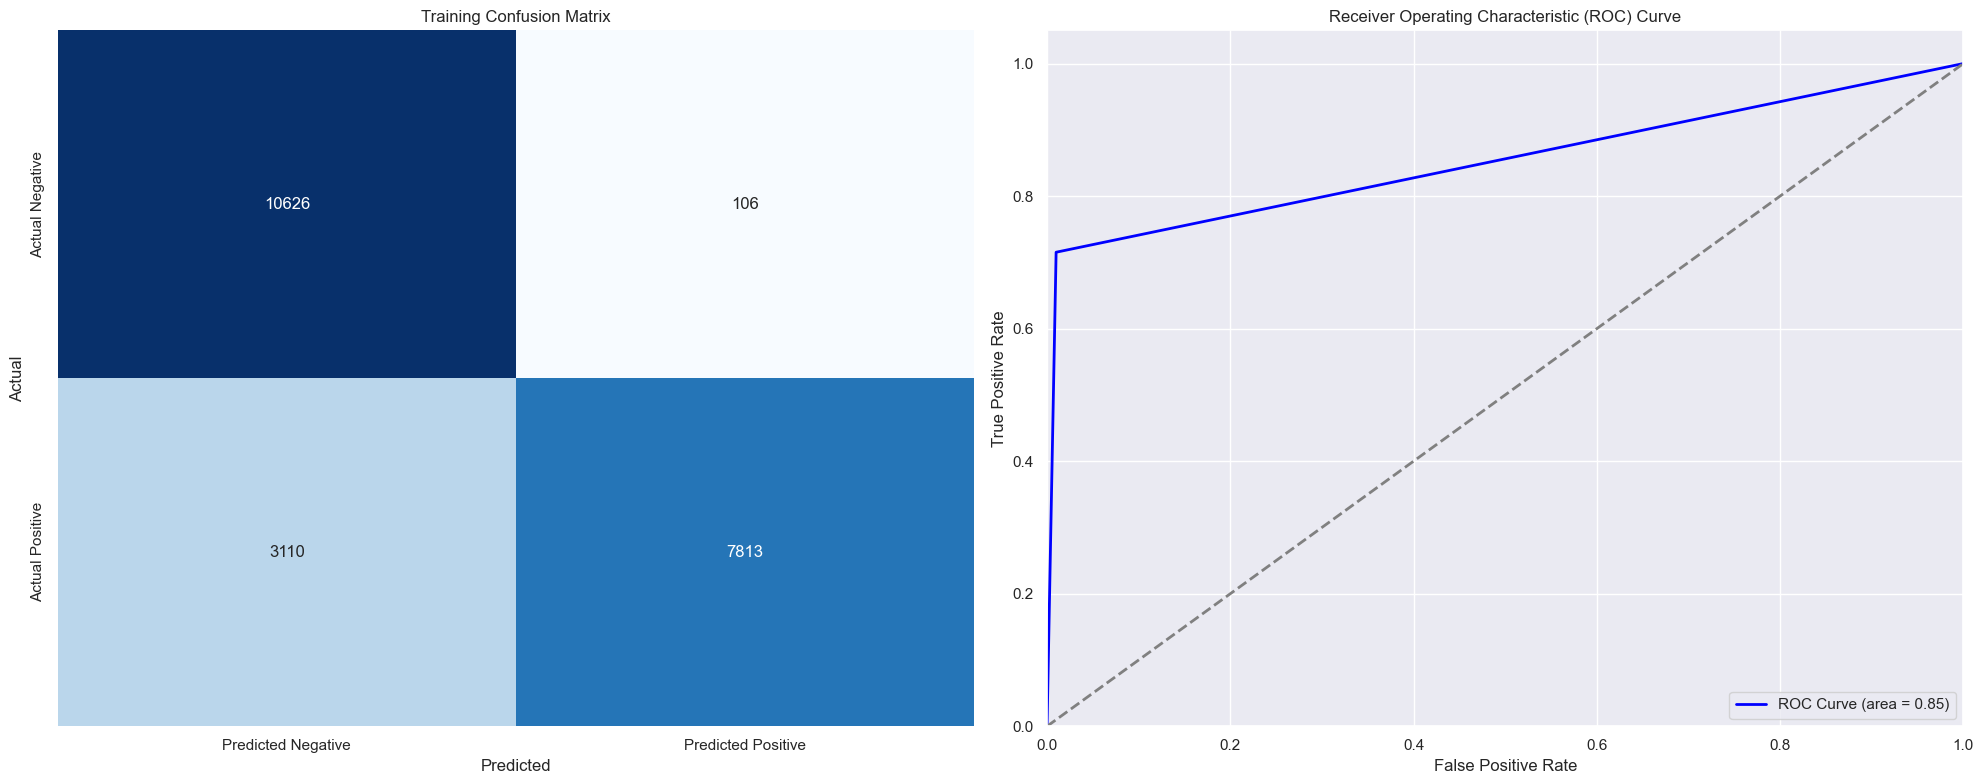

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833
2,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.837959,0.709237,0.815345,0.826671,0.958787,0.968971,0.839104
3,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841707,0.716587,0.820373,0.830395,0.959314,0.969064,0.842826
4,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.851489,0.715280,0.829317,0.849321,0.986614,0.990123,0.852701


In [41]:
# initialize variables
algorithm = 'XGBClassifier'
desc = f'{algorithm} + {msg}'
model = 'xgb_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.98      0.86      2683
        True       0.98      0.71      0.82      2731

    accuracy                           0.85      5414
   macro avg       0.87      0.85      0.84      5414
weighted avg       0.87      0.85      0.84      5414



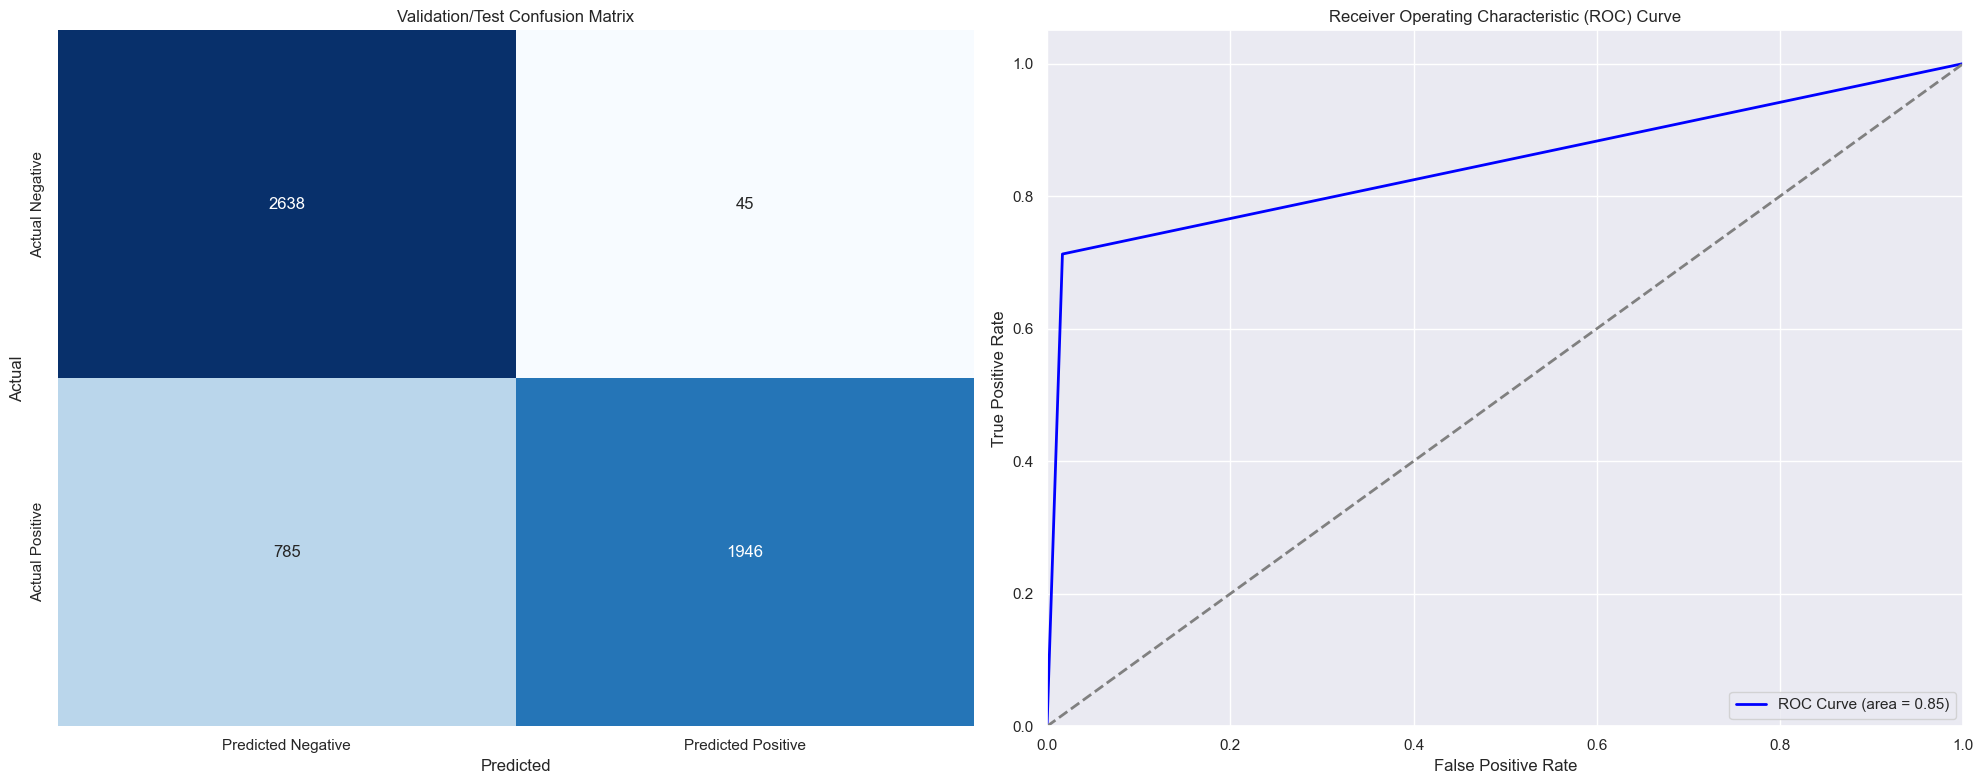

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833
2,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.837959,0.709237,0.815345,0.826671,0.958787,0.968971,0.839104
3,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841707,0.716587,0.820373,0.830395,0.959314,0.969064,0.842826
4,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.851489,0.715280,0.829317,0.849321,0.986614,0.990123,0.852701
5,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.846694,0.712560,0.824227,0.841449,0.977398,0.983228,0.847894


In [42]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

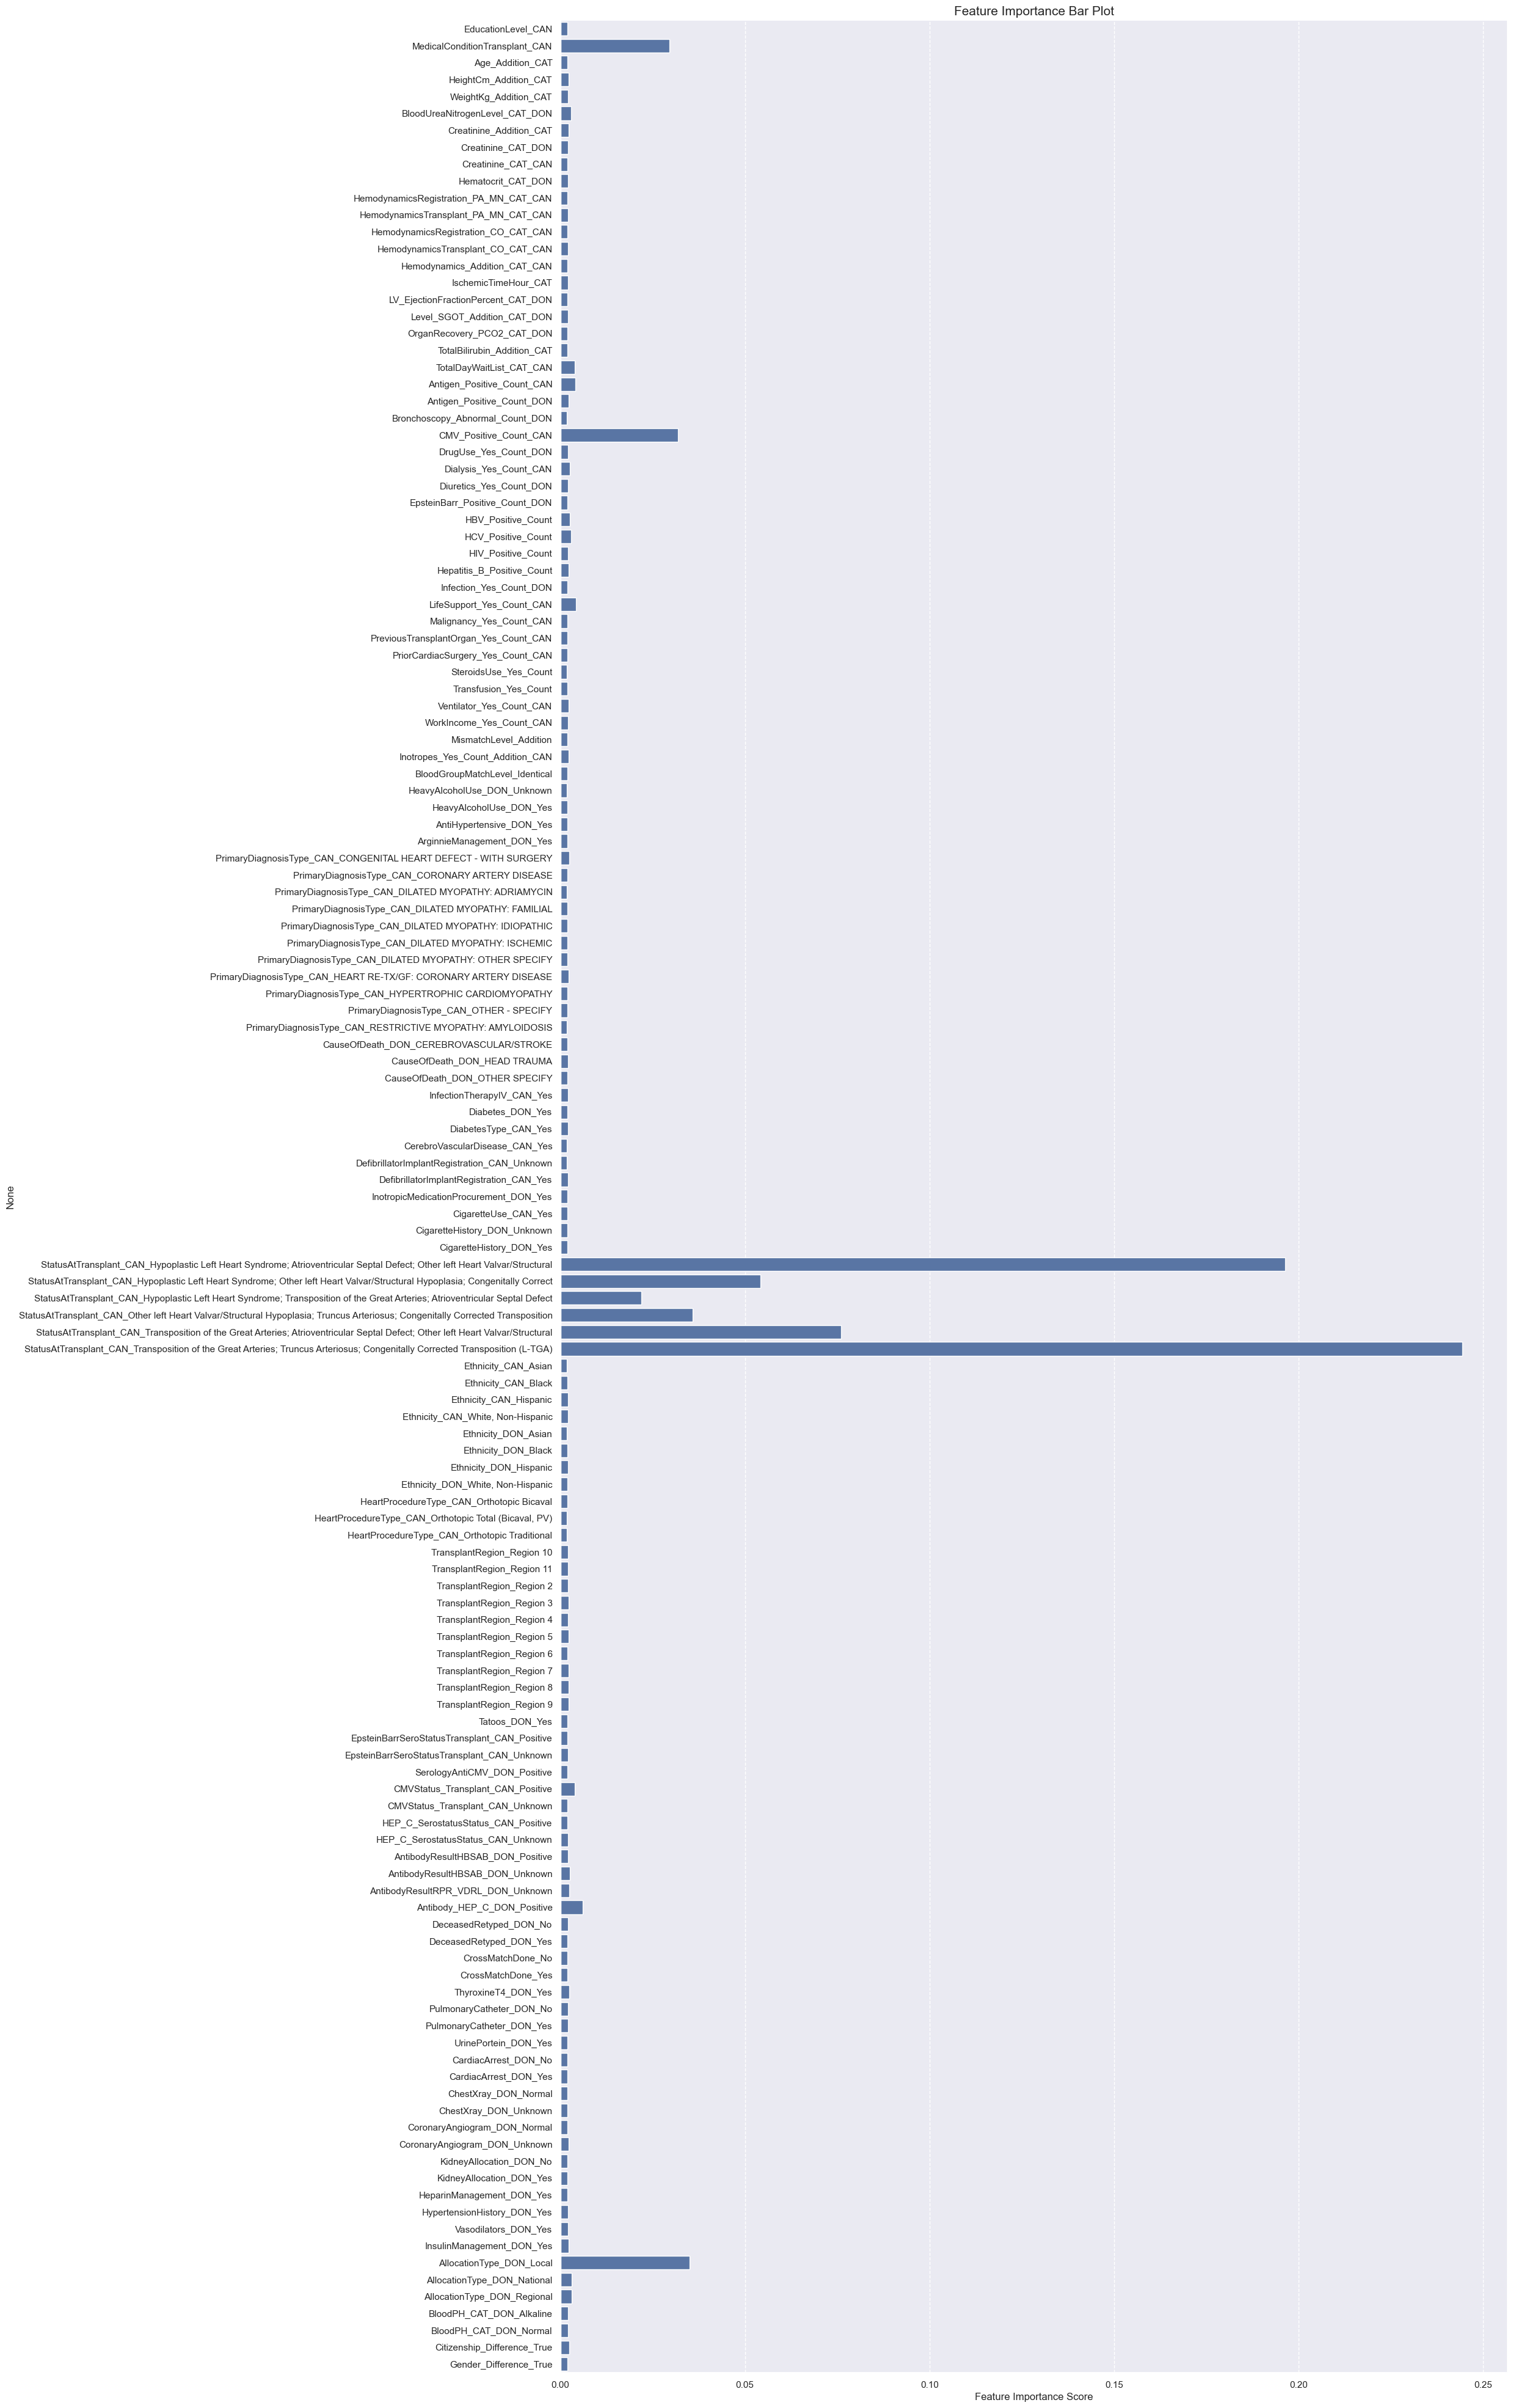

In [43]:
df_xgb = umf.plot_feature_importance(Model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [44]:
df_xgb.sort_values(by = 'Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.244307
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.196389
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.076030
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.054163
StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition,0.035814
AllocationType_DON_Local,0.034952
CMV_Positive_Count_CAN,0.031797
MedicalConditionTransplant_CAN,0.029524
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,0.021970
Antibody_HEP_C_DON_Positive,0.005942


### KNN
- `K-Nearest Neighbors (KNN)`
    - Type: Instance-based learning (lazy learning)
    - Mechanism: Classifies a data point based on the majority class among its k-nearest neighbors.
    - Pros: Simple, intuitive, no training phase.
    - Cons: Computationally expensive during prediction, sensitive to irrelevant features and the choice of k.

In [45]:
# import library
from sklearn.neighbors import KNeighborsClassifier

# define the search space
search_space = parms.knn_search_space()

# create a KNN model
Model = KNeighborsClassifier(n_jobs=-1)

# Hyper-Parameter tuning
knn_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = knn_fit

/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3), np.int64(20), np.int64(1), np.str_('distance')] before, using random point [np.int64(35), np.int64(10), 2, 'distance']
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/envs/survival_env/lib/python3.9/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(3), np.int64(20), np.int64(1), np.str_('distance')] before, using random point [np.int64(20), np.int64(10), 2, 'uniform']
  warnings.warn(


Best parameters found: OrderedDict([('leaf_size', 50), ('n_neighbors', 20), ('p', 1), ('weights', 'distance')])
Best score achieved: 0.5743884929163645

Current Model Parameters:
 KNeighborsClassifier(leaf_size=50, n_jobs=-1, n_neighbors=20, p=1,
                     weights='distance')


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       1.00      1.00      1.00     10732
        True       1.00      1.00      1.00     10923

    accuracy                           1.00     21655
   macro avg       1.00      1.00      1.00     21655
weighted avg       1.00      1.00      1.00     21655



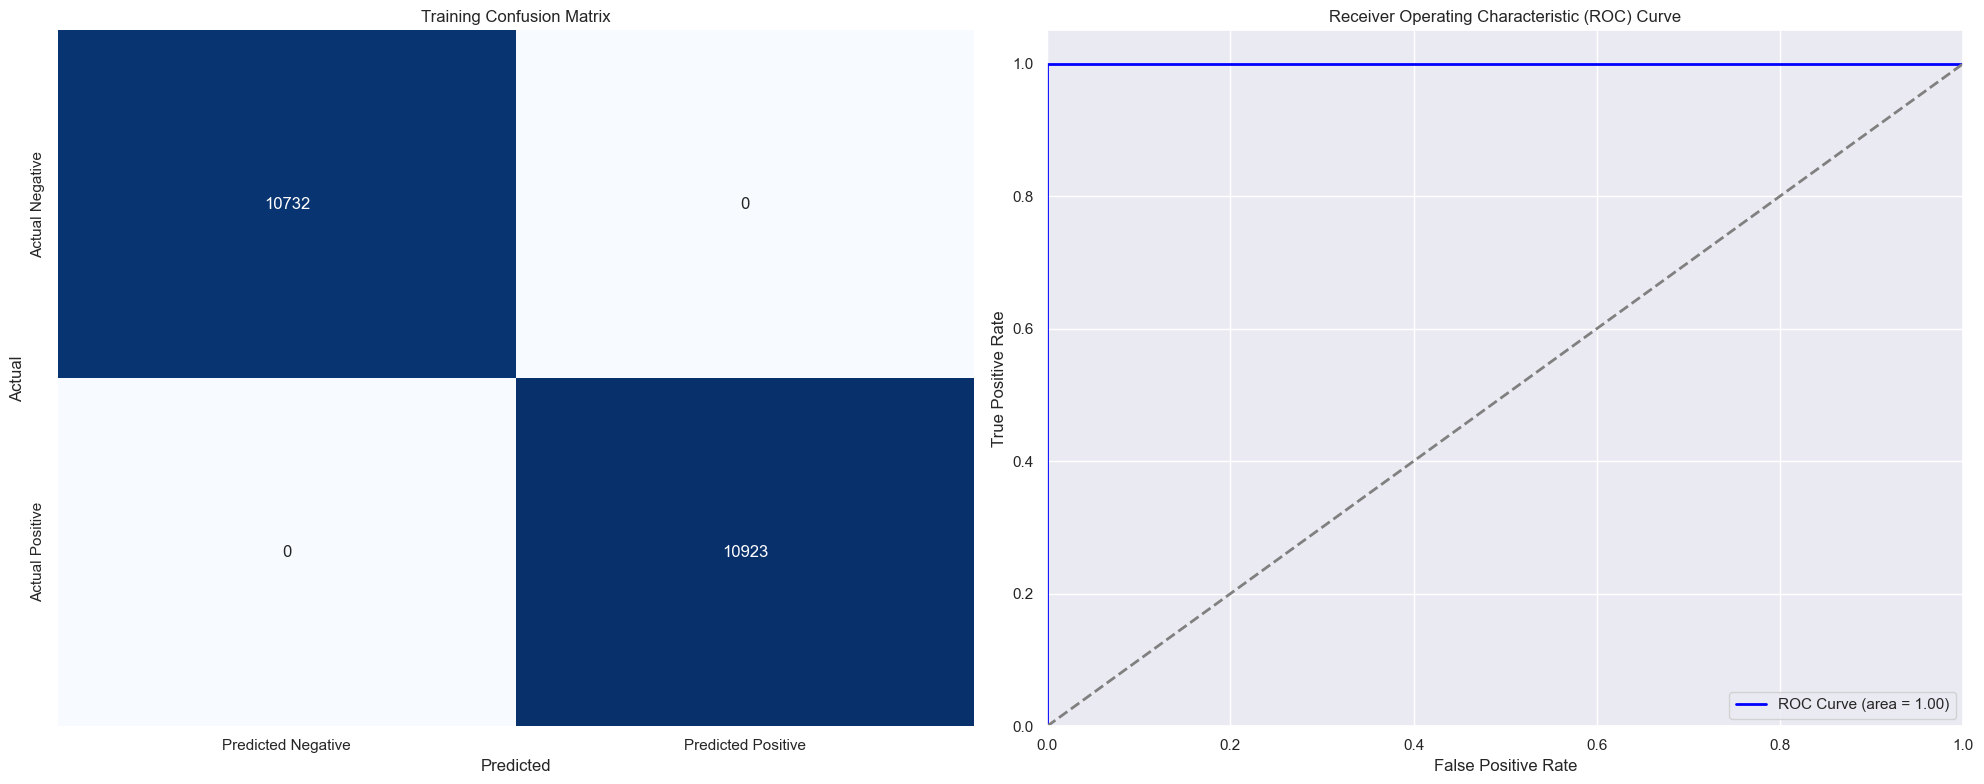

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833
2,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.837959,0.709237,0.815345,0.826671,0.958787,0.968971,0.839104
3,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841707,0.716587,0.820373,0.830395,0.959314,0.969064,0.842826
4,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.851489,0.715280,0.829317,0.849321,0.986614,0.990123,0.852701
5,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.846694,0.712560,0.824227,0.841449,0.977398,0.983228,0.847894
6,KNN,knn_fit,KNN + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [46]:
# initialize variables
algorithm = 'KNN'
desc = f'{algorithm} + {msg}'
model = 'knn_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.73      0.89      0.80      2683
        True       0.86      0.68      0.76      2731

    accuracy                           0.78      5414
   macro avg       0.80      0.78      0.78      5414
weighted avg       0.80      0.78      0.78      5414



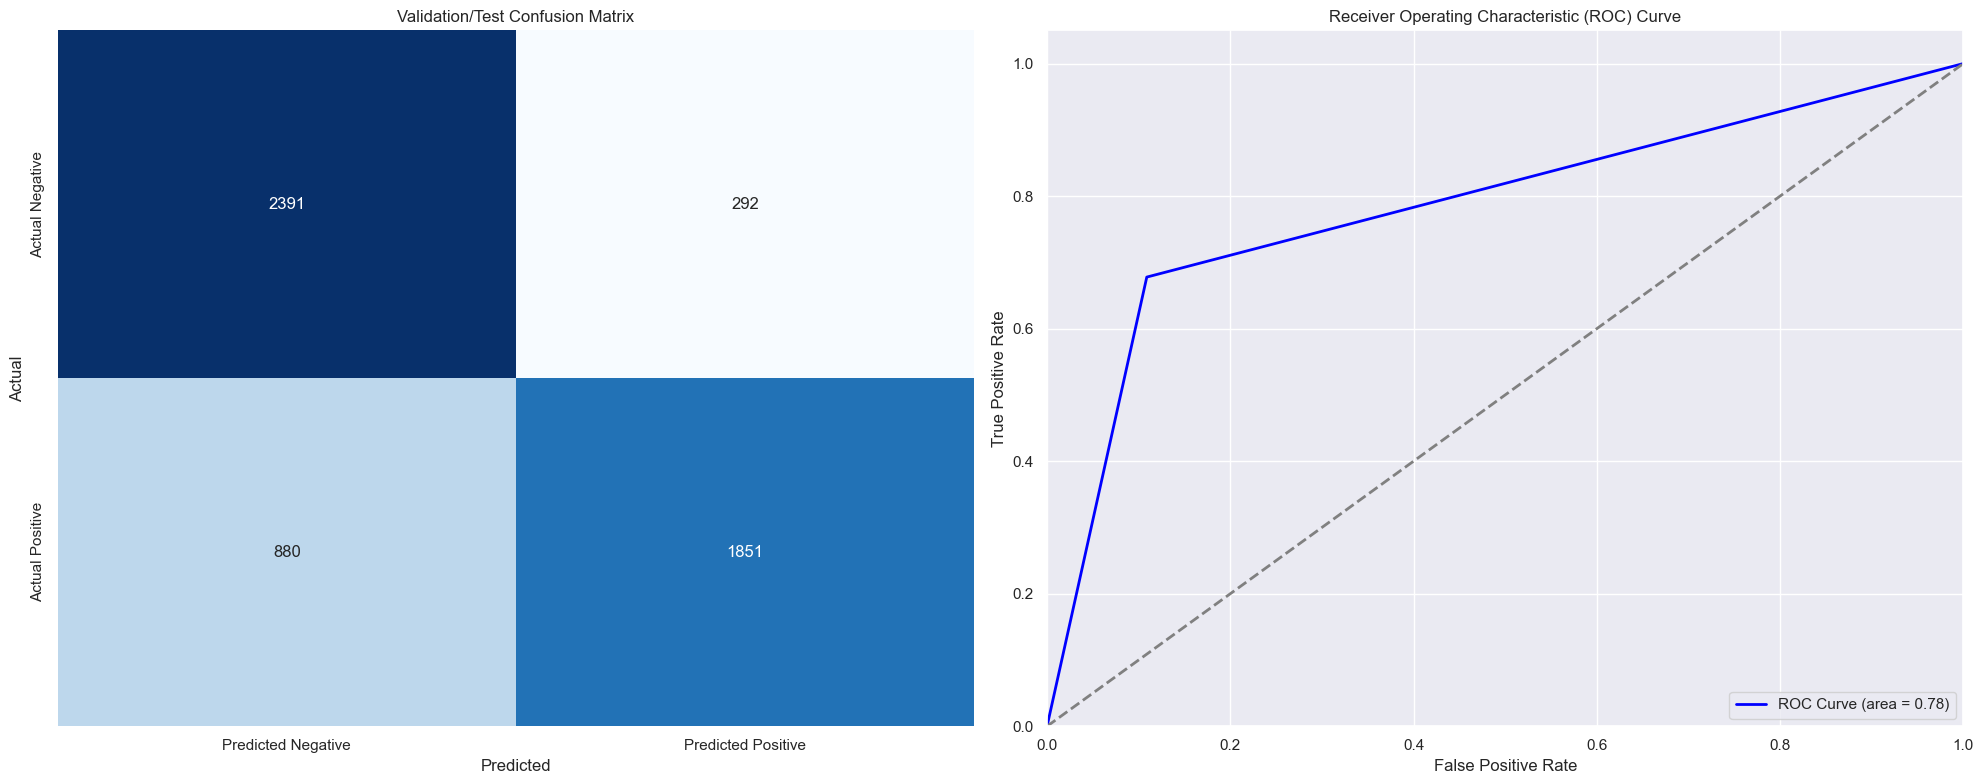

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833
2,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.837959,0.709237,0.815345,0.826671,0.958787,0.968971,0.839104
3,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841707,0.716587,0.820373,0.830395,0.959314,0.969064,0.842826
4,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.851489,0.715280,0.829317,0.849321,0.986614,0.990123,0.852701
5,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.846694,0.712560,0.824227,0.841449,0.977398,0.983228,0.847894
6,KNN,knn_fit,KNN + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.783524,0.677774,0.759540,0.747963,0.863742,0.891167,0.784470


In [47]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

##### Note: Clearly overfitting!

### AdaBoostClassifier

In [48]:
# import library
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# define the search space
search_space = parms.ada_search_space()

# base estimater
estimator = DecisionTreeClassifier(max_depth=1)

# create a AdaBoost model
Model = AdaBoostClassifier(estimator=estimator, algorithm='SAMME', random_state=RANDOM_STATE)

# Hyper-Parameter tuning
ada_fit = umf.bayesian_optimize(Model, X_train, y_train, search_space, youden_scorer, n_jobs=-1, n_iter=64, n_splits=5, seed=RANDOM_STATE)

# best model
Model = ada_fit

Best parameters found: OrderedDict([('learning_rate', 1.0060568590894214), ('n_estimators', 500)])
Best score achieved: 0.6732645684186868

Current Model Parameters:
 AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=1.0060568590894214, n_estimators=500,
                   random_state=1776)


#### Train

***** Classification Metrics for Training:
Classification Report:
               precision    recall  f1-score   support

       False       0.76      0.97      0.85     10732
        True       0.95      0.71      0.81     10923

    accuracy                           0.84     21655
   macro avg       0.86      0.84      0.83     21655
weighted avg       0.86      0.84      0.83     21655



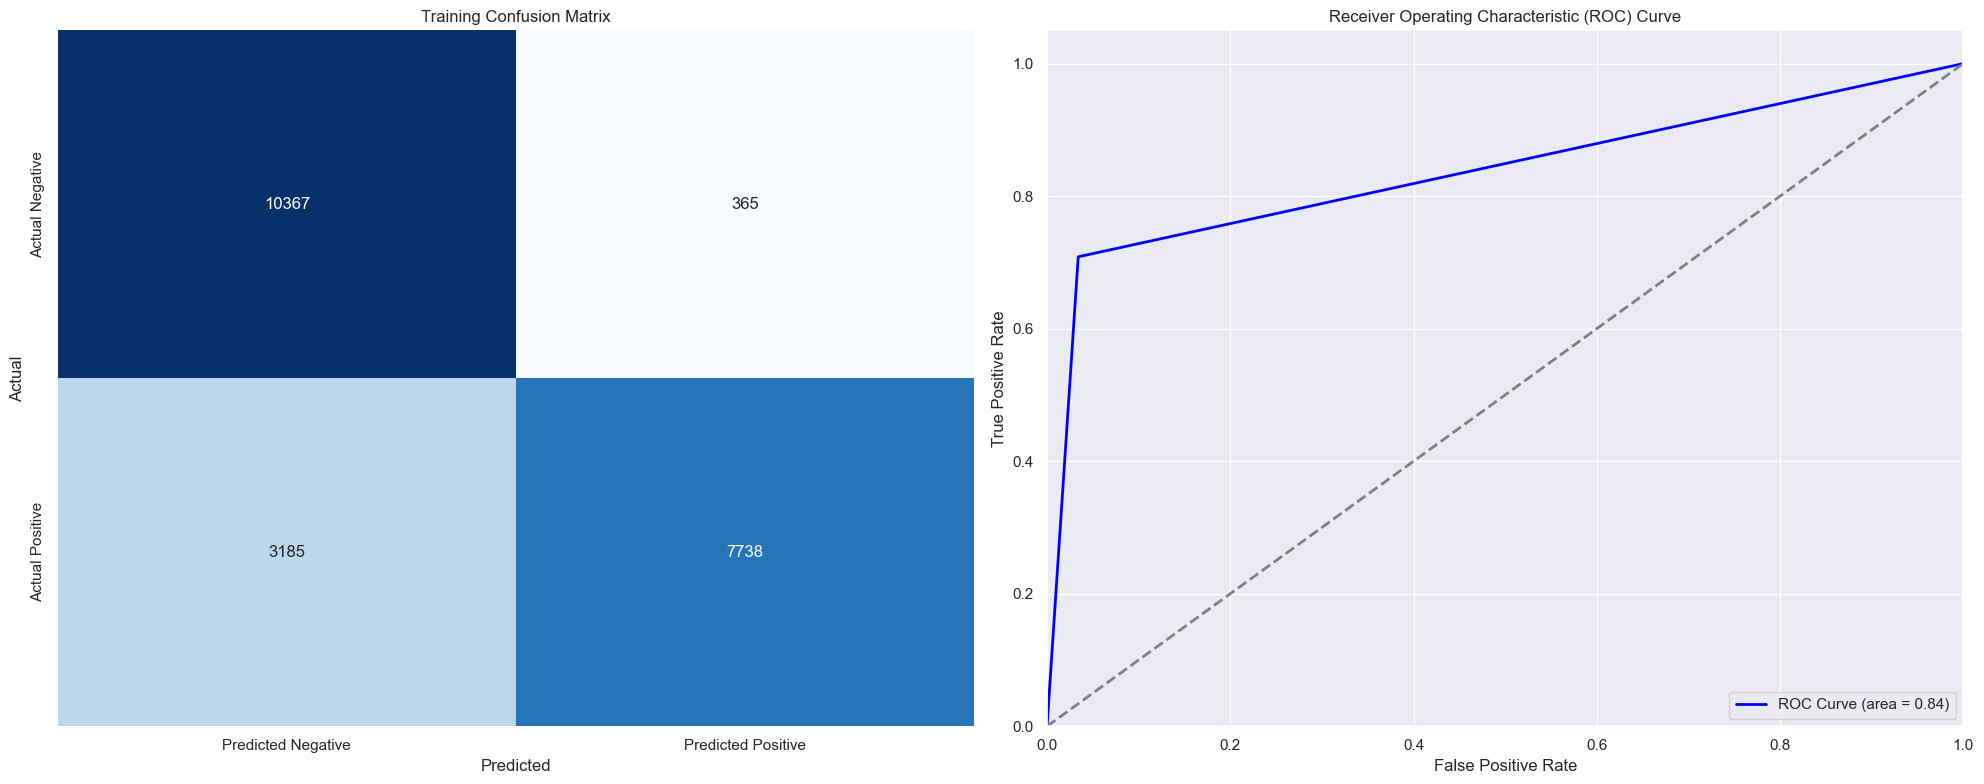

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833
2,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.837959,0.709237,0.815345,0.826671,0.958787,0.968971,0.839104
3,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841707,0.716587,0.820373,0.830395,0.959314,0.969064,0.842826
4,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.851489,0.715280,0.829317,0.849321,0.986614,0.990123,0.852701
5,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.846694,0.712560,0.824227,0.841449,0.977398,0.983228,0.847894
6,KNN,knn_fit,KNN + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.783524,0.677774,0.759540,0.747963,0.863742,0.891167,0.784470
8,AdaBoost,ada_fit,AdaBoost + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.836066,0.708413,0.813413,0.823582,0.954955,0.965990,0.837202


In [49]:
# initialize variables
algorithm = 'AdaBoost'
desc = f'{algorithm} + {msg}'
model = 'ada_fit'
data_type = 'Training'

# display
df_classfication, threshold = umf.classification_main(algorithm, model, desc, Model, X_train, y_train, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Test

***** Classification Metrics for Validation/Test:
Classification Report:
               precision    recall  f1-score   support

       False       0.77      0.96      0.86      2683
        True       0.95      0.72      0.82      2731

    accuracy                           0.84      5414
   macro avg       0.86      0.84      0.84      5414
weighted avg       0.86      0.84      0.84      5414



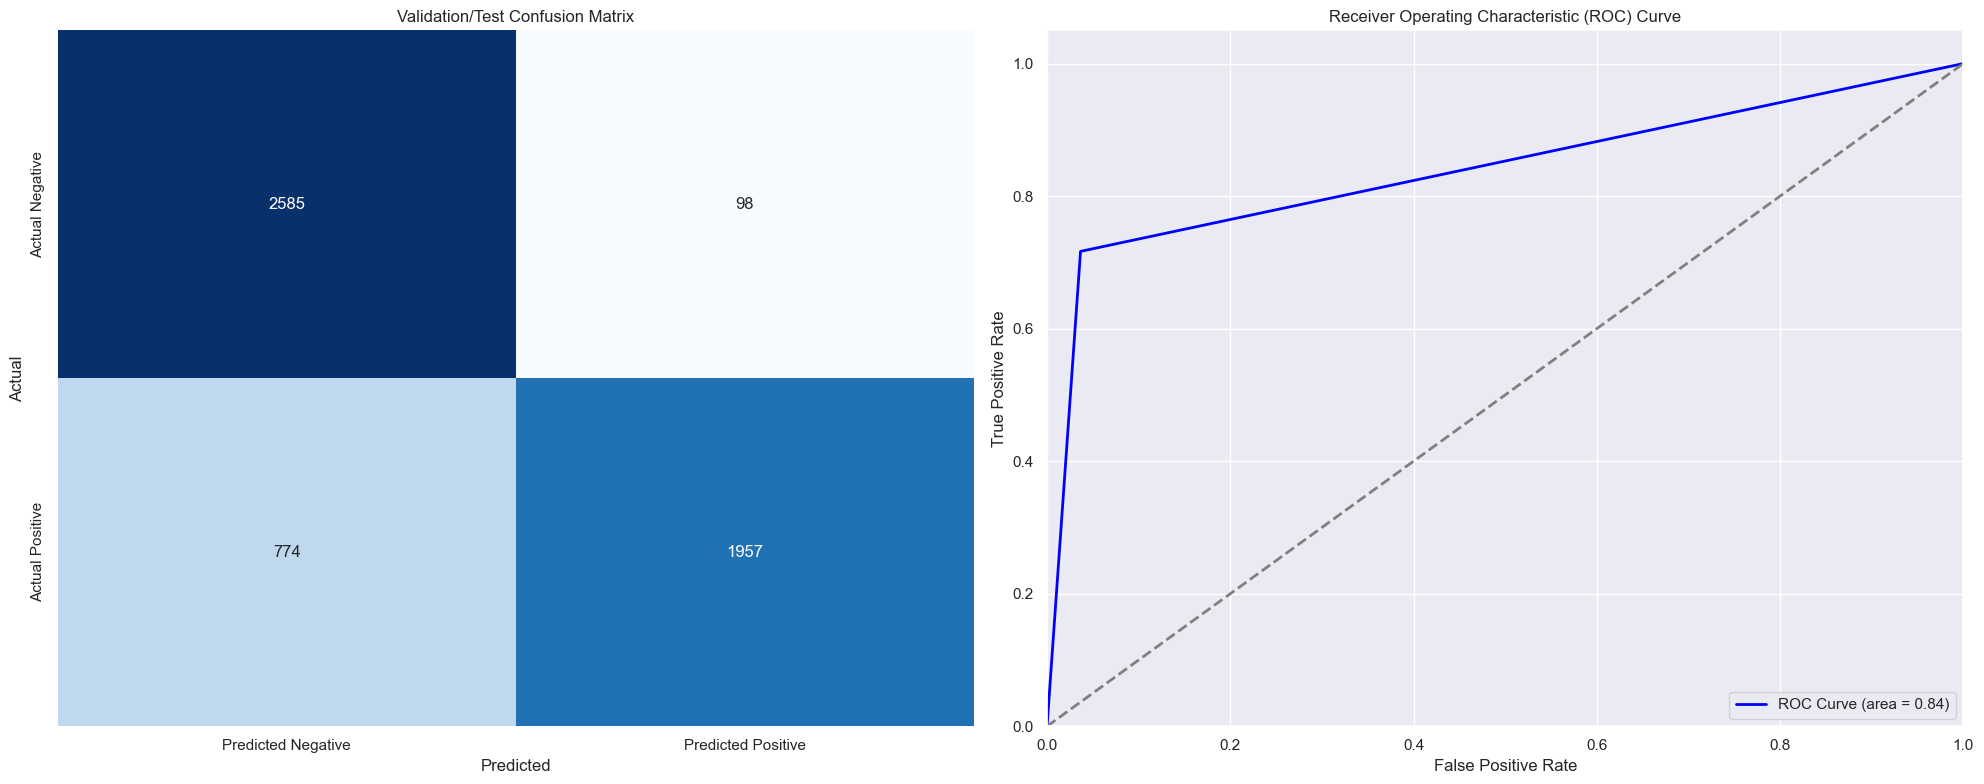

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
0,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.846594,0.719033,0.825434,0.838316,0.968792,0.976426,0.847729
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833
2,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.837959,0.709237,0.815345,0.826671,0.958787,0.968971,0.839104
3,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841707,0.716587,0.820373,0.830395,0.959314,0.969064,0.842826
4,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.851489,0.715280,0.829317,0.849321,0.986614,0.990123,0.852701
5,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.846694,0.712560,0.824227,0.841449,0.977398,0.983228,0.847894
6,KNN,knn_fit,KNN + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,KNN,knn_fit,KNN + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.783524,0.677774,0.759540,0.747963,0.863742,0.891167,0.784470
8,AdaBoost,ada_fit,AdaBoost + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Training,0.836066,0.708413,0.813413,0.823582,0.954955,0.965990,0.837202
9,AdaBoost,ada_fit,AdaBoost + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.838936,0.716587,0.817802,0.825377,0.952311,0.963474,0.840031


In [50]:
# initialize variable
data_type = 'Validation/Test'

# display
df_classfication, _ = umf.classification_main(algorithm, model, desc, Model, X_test, y_test, data_type, metric_df=df_classfication, train_threshold=None)
df_classfication

#### Feature Importance

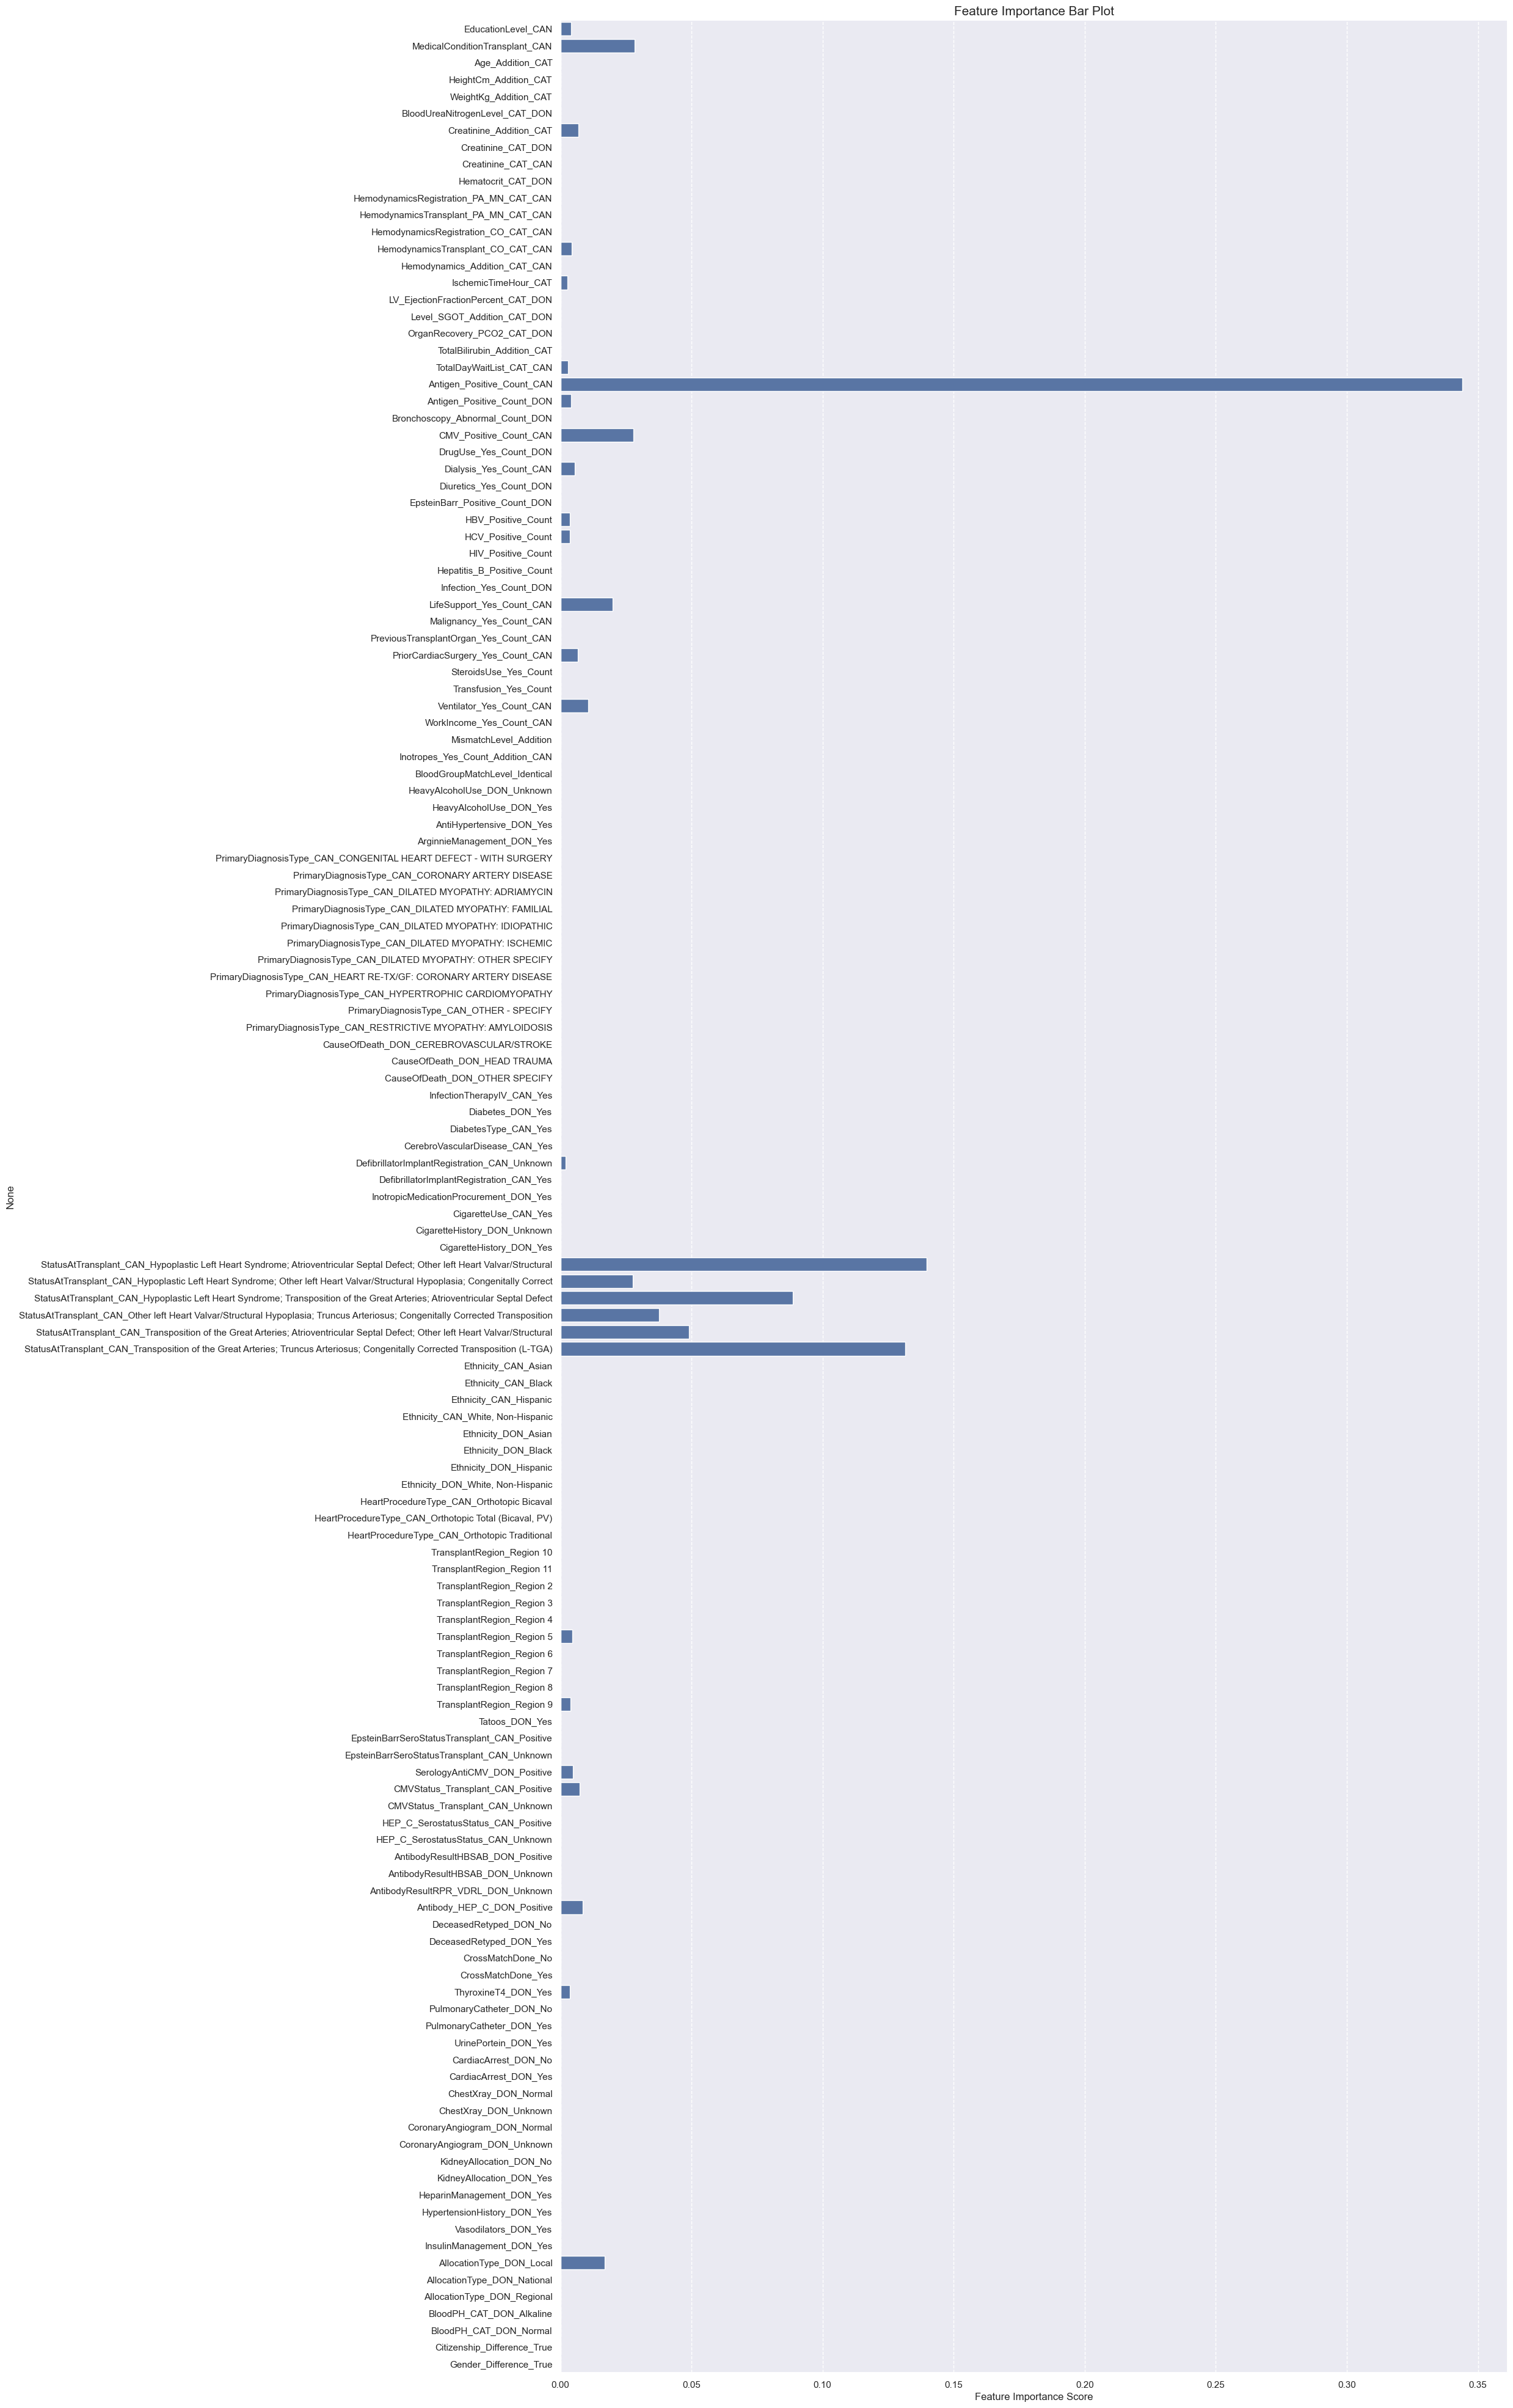

In [51]:
df_ada = umf.plot_feature_importance(Model, pd.DataFrame(X_train, columns=X_train.columns.to_list()),figsize=(20,50))

In [52]:
df_ada.sort_values(by = 'Feature Importance Score', ascending=False).head(20)

,Feature Importance Score
Antigen_Positive_Count_CAN,0.344014
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.139677
StatusAtTransplant_CAN_Transposition of the Great Arteries; Truncus Arteriosus; Congenitally Corrected Transposition (L-TGA),0.131518
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Transposition of the Great Arteries; Atrioventricular Septal Defect,0.088692
StatusAtTransplant_CAN_Transposition of the Great Arteries; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,0.049073
StatusAtTransplant_CAN_Other left Heart Valvar/Structural Hypoplasia; Truncus Arteriosus; Congenitally Corrected Transposition,0.037580
MedicalConditionTransplant_CAN,0.028201
CMV_Positive_Count_CAN,0.027840
StatusAtTransplant_CAN_Hypoplastic Left Heart Syndrome; Other left Heart Valvar/Structural Hypoplasia; Congenitally Correct,0.027617
LifeSupport_Yes_Count_CAN,0.019855


## Model Performance

In [53]:
# display
filtered_df = df_classfication[df_classfication.DataType != 'Training']
filtered_df.sort_values(by=['Accuracy', 'ROC_AUC_Score'], ascending=False)

,Algorithm,Model,Description,DataType,Accuracy,RecallSensitivity,F1Score,AveragePrecision,Precision,Specificity,ROC_AUC_Score
5,XGBClassifier,xgb_fit,XGBClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.846694,0.712560,0.824227,0.841449,0.977398,0.983228,0.847894
1,RandomForestClassifier,rfc_fit,RandomForestClassifier + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.843738,0.721347,0.823234,0.832072,0.958637,0.968319,0.844833
3,LogisticRegression,lrc_fit,LogisticRegression + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.841707,0.716587,0.820373,0.830395,0.959314,0.969064,0.842826
9,AdaBoost,ada_fit,AdaBoost + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.838936,0.716587,0.817802,0.825377,0.952311,0.963474,0.840031
7,KNN,knn_fit,KNN + 2011-2016: Discretization - Bayesian Search with Custom Score Function (youdens_j_score) - Features where Max Gini Impurity < 5% removed,Validation/test,0.783524,0.677774,0.759540,0.747963,0.863742,0.891167,0.784470


## Save Model to Disk

In [54]:
import joblib

# save the model to a file
print(joblib.dump(xgb_fit, '../Models/XGBmodel_Discretization_Bayesian.joblib'))
print(joblib.dump(lrc_fit, '../Models/LRmodel_Discretization_Bayesian.joblib'))
print(joblib.dump(rfc_fit, '../Models/RFmodel_Discretization_Bayesian.joblib'))
print(joblib.dump(ada_fit, '../Models/ADAmodel_Discretization_Bayesian.joblib'))

# load the model from the file
# loaded_model = joblib.load('../Models/KNN_Threshold.joblib')

# write dataset - # X_train, y_train, X_test, y_test files
uf.write_to_file(X_train, 'X_train_GINI',path='../Data/XyData/', format='pkl')
uf.write_to_file(y_train, 'y_train_GINI',path='../Data/XyData/', format='pkl')
uf.write_to_file(X_test, 'X_test_GINI',path='../Data/XyData/', format='pkl')
uf.write_to_file(y_test, 'y_test_GINI',path='../Data/XyData/', format='pkl')

['../Models/XGBmodel_Discretization_Bayesian.joblib']
['../Models/LRmodel_Discretization_Bayesian.joblib']
['../Models/RFmodel_Discretization_Bayesian.joblib']
['../Models/ADAmodel_Discretization_Bayesian.joblib']
21,655 records written to ../Data/XyData/X_train_GINI.pkl
21,655 records written to ../Data/XyData/y_train_GINI.pkl
5,414 records written to ../Data/XyData/X_test_GINI.pkl
5,414 records written to ../Data/XyData/y_test_GINI.pkl
